In [1]:
import MDAnalysis as mda
import prolif as plf
from rdkit import Chem
import os
from collections import defaultdict
import pandas as pd
import sys
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from decimal import Decimal
from rdkit.ML.Scoring.Scoring import CalcBEDROC
from scipy.integrate import trapezoid
from scipy import stats
from rdkit import Chem
from rdkit.Chem import PandasTools, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)
Failed to patch pandas - PandasTools will have limited functionality


## Metrics

In [2]:
def enrichment_factor(df: pd.DataFrame, fraction: float) -> float:
    df = df.sort_values("score", ascending=False)

    n_total = len(df)
    n_top = max(1, int(np.ceil(n_total * fraction)))


    n_actives = df["active"].sum()
    n_actives_in_top = df.head(n_top)["active"].sum()

    return (
        (n_actives_in_top / n_top)
        /
        (n_actives / n_total)
    )

def bedroc(df: pd.DataFrame, col: int, alpha: float) -> float:
    bedroc = CalcBEDROC(
        list(zip(df["score"], df["active"])),
        col=col,
        alpha=alpha
    )
    return bedroc

# Adapted from Oscar's notebook
def interpolate_curve(points):
    i = 0
    while i < len(points) and points[i][0] == 0:
        i += 1
    slope = (points[i][1] - points[i-1][1])/(points[i][0] - points[i-1][0])
    intercept = points[i][1] - slope * points[i][0]
    point_one =  [0.100001, (slope * 0.100001 + intercept)]
    npoints = [x for x in points]
    npoints.insert(i, point_one)
    return npoints

def logAUC(y_true, y_pred) -> float:
    # constants
	## If you modify also change in plots.py
    LOGAUC_MAX = 1.0 ## this should not change
    LOGAUC_MIN = 0.001 ## this you may want to change if your database is large and you have strong early enrichment.
    RANDOM_LOGAUC = (LOGAUC_MAX-LOGAUC_MIN)/np.log(10)/np.log10(LOGAUC_MAX/LOGAUC_MIN)

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    points = list(zip(fpr*100, tpr*100))
    points = interpolate_curve(points)


	# assumes we have previously interpolated to get y-value at x = 0.1% 
	# generate new points array clamped between 0.1% and 100%
    npoints = []
    for x in points:
        if (x[0] >= LOGAUC_MIN*100) and (x[0] <= LOGAUC_MAX*100):
            npoints.append( [x[0]/100, x[1]/100] )

    area = 0.0
    for point2, point1 in zip(npoints[1:], npoints[:-1]):
        if point2[0] - point1[0] < 0.000001:
            continue

        # segment area computed as integral of log transformed equation
        dx = point2[0]-point1[0]
        dy = point2[1]-point1[1]
        intercept = point2[1] - dy/dx * point2[0]
        area += dy/np.log(10) + intercept*(np.log10(point2[0])-np.log10(point1[0]))

    return area / np.log10(LOGAUC_MAX/LOGAUC_MIN) - RANDOM_LOGAUC

def logAUC_OSCAR(points):
    # constants
	## if you modify also change in plots.py        
	LOGAUC_MAX = 1.0   ## this should not change
	LOGAUC_MIN = 0.001 ## this you may want to change if you database is large and you have strong early enrichment. 
	RANDOM_LOGAUC = (LOGAUC_MAX-LOGAUC_MIN)/np.log(10)/np.log10(LOGAUC_MAX/LOGAUC_MIN)


	"""Compute semilog x AUC minus the perfectly random semilog AUC."""
	# assumes we have previously interpolated to get y-value at x = 0.1% 
	# generate new points array clamped between 0.1% and 100%

	npoints = []
	for x in points:
		if (x[0] >= LOGAUC_MIN*100) and (x[0] <= LOGAUC_MAX*100):
			npoints.append( [x[0]/100 , x[1]/100] )

	area = 0.0
	for point2, point1 in zip(npoints[1:], npoints[:-1]):
		if point2[0] - point1[0] < 0.000001:
			continue

		# segment area computed as integral of log transformed equation
		dx = point2[0]-point1[0]
		dy = point2[1]-point1[1]
		intercept = point2[1] - (dy)/(dx) * point2[0]
		area += dy/np.log(10) + intercept*(np.log10(point2[0])-np.log10(point1[0]))

	# print("logAUC", area, area/np.log10(LOGAUC_MAX/LOGAUC_MIN) - RANDOM_LOGAUC)
	return area/np.log10(LOGAUC_MAX/LOGAUC_MIN) - RANDOM_LOGAUC
    

# Loading and cleaning data

In [3]:
# Import all pickled IFP dictionaries from prolif_fps directory

IFP_pickles = [file for file in os.listdir('./prolif_fps') if file.endswith('.pkl')]

IFP_dicts = {}

for pickle in IFP_pickles:
    temp_dict = pd.read_pickle(f"./prolif_fps/{pickle}")
    key = list(temp_dict.keys())[0]
    IFP_dicts[key] = temp_dict[key]



# Clean up column levels

for run_key, run_dict in IFP_dicts.items():
    for conformer_key, conformer_dict in IFP_dicts[run_key].items():
        for ligand_key, ligand_list in IFP_dicts[run_key][conformer_key].items():
            # remove superfluous ligand columns level 
            ligand_list[1].columns = ligand_list[1].columns.droplevel("ligand")
            # merge protein and interaction column level
            ligand_list[1].columns = ligand_list[1].columns.map("_".join)
            if "_" in ligand_list[1].columns:
                ligand_list[1].rename(columns={'_': 'LigName'}, inplace=True)

# Summary stats of IFP counts, enrichments

In [4]:
IFP_frequencies = {}

for run_key, run_dict in IFP_dicts.items():
    IFP_frequencies[run_key] = {}

    for conformer_key, conformer_dict in IFP_dicts[run_key].items():

        ligand_keys = list(conformer_dict.keys())
        actives_key = [key for key in ligand_keys if key.endswith("true_actives.sdf")][0]
        inactives_key = [key for key in ligand_keys if key.endswith("true_inactives.sdf")][0]
        decoys_key = [key for key in ligand_keys if key.endswith("decoys.sdf")][0]

        actives = IFP_dicts[run_key][conformer_key][actives_key][1].copy()
        if 'LigName' in actives.columns:
            actives.drop('LigName', axis=1, inplace=True)
        freq_actives = actives.mean(axis=0)
        freq_actives.name = 'freq_actives'

        inactives = IFP_dicts[run_key][conformer_key][inactives_key][1].copy()
        if 'LigName' in inactives.columns:
            inactives.drop('LigName', axis=1, inplace=True)
        freq_inactives = inactives.mean(axis=0)
        freq_inactives.name = 'freq_inactives'

        decoys = IFP_dicts[run_key][conformer_key][decoys_key][1].copy()
        if 'LigName' in decoys.columns:
            decoys.drop('LigName', axis=1, inplace=True)
        freq_decoys = decoys.mean(axis=0)
        freq_decoys.name = 'freq_decoys'

        new_df = pd.concat(
            [
                freq_actives.rename("freq_actives"),
                freq_inactives.rename("freq_inactives"),
                freq_decoys.rename("freq_decoys"),

            ],
            axis = 1
        )

        new_df['ER_actives_decoys'] = new_df['freq_actives'] / new_df['freq_decoys']
        new_df['Log2_ER_actives_decoys'] = np.log2(new_df['ER_actives_decoys'])

        new_df['ER_actives_inactives'] = new_df['freq_actives'] / new_df['freq_inactives']
        new_df['Log2_ER_actives_inactives'] = np.log2(new_df['ER_actives_inactives'])
        
        IFP_frequencies[run_key][conformer_key] = new_df



In [5]:
IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf']

,freq_actives,freq_inactives,freq_decoys,ER_actives_decoys,Log2_ER_actives_decoys,ER_actives_inactives,Log2_ER_actives_inactives
LEU363.A_VdWContact,0.070175,0.059524,0.161109,0.435578,-1.198997,1.178947,0.237499
ASP366.A_Hydrophobic,0.192982,0.250000,0.372447,0.518148,-0.948565,0.771930,-0.373458
ASP366.A_VdWContact,0.333333,0.583333,0.711755,0.468326,-1.094415,0.571429,-0.807355
ILE369.A_Hydrophobic,0.245614,0.202381,0.190079,1.292167,0.369792,1.213622,0.279319
ILE369.A_VdWContact,0.438596,0.452381,0.493122,0.889428,-0.169051,0.969529,-0.044644
...,...,...,...,...,...,...,...
ARG545.B_Anionic,NaN,NaN,0.007712,NaN,NaN,NaN,NaN
ARG545.B_PiCation,NaN,NaN,0.008962,NaN,NaN,NaN,NaN
LYS547.B_Hydrophobic,NaN,NaN,0.005836,NaN,NaN,NaN,NaN
LYS547.B_Anionic,NaN,NaN,0.043977,NaN,NaN,NaN,NaN


In [6]:
df = IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf'].dropna()
df.sort_values(by='freq_actives', ascending=False).head()


,freq_actives,freq_inactives,freq_decoys,ER_actives_decoys,Log2_ER_actives_decoys,ER_actives_inactives,Log2_ER_actives_inactives
GLU543.B_VdWContact,0.982456,0.928571,0.871822,1.126900,0.172360,1.058030,0.081380
GLU543.A_VdWContact,0.982456,0.940476,0.895790,1.096748,0.133233,1.044637,0.063002
GLU543.A_Hydrophobic,0.947368,0.785714,0.547937,1.728974,0.789917,1.205742,0.269921
GLU543.B_Hydrophobic,0.947368,0.928571,0.696332,1.360513,0.444151,1.020243,0.028913
HIS456.B_VdWContact,0.736842,0.571429,0.445602,1.653587,0.725599,1.289474,0.366782


# Binary Logistic regression model to find IFP weights

## Prepare actives/decoys datasets

I am not including the non-active Montpellier ligands to prevent data leakage.

In [5]:
montpellier_ligand_data = pd.read_csv("./results/montpellier_ligands.csv")
true_actives = montpellier_ligand_data[montpellier_ligand_data["ACTIVE_LABEL"] == True]["ID"].tolist()


#true_actives_ligand_names = true_actives["ID"].tolist()

# 4H2I_C_4

actives_docking_4h2i_c_4 = pd.read_csv("./results/12Jun_rg/all_montpellier_4h2i_c_4_dimer.csv")[["LigName", "docking_score"]]
actives_docking_4h2i_c_4 = actives_docking_4h2i_c_4[actives_docking_4h2i_c_4["LigName"].isin(true_actives)]

actives_4h2i_c_4 = IFP_dicts['12Jun_rg']['4h2i_c_4_dimer_sdf']['4h2i_c_4_dimer_true_actives.sdf'][1]
actives_4h2i_c_4['Active'] = True
actives_4h2i_c_4 = actives_4h2i_c_4.merge(actives_docking_4h2i_c_4, on="LigName")

decoys_docking_4h2i_c_4 = pd.read_csv("./results/12Jun_rg/all_decoys_4h2i_c_4_dimer.csv")[["LigName", "docking_score"]]
decoys_4h2i_c_4 = IFP_dicts['12Jun_rg']['4h2i_c_4_dimer_sdf']['4h2i_c_4_dimer_decoys.sdf'][1]
decoys_4h2i_c_4['Active'] = False
decoys_4h2i_c_4 = decoys_4h2i_c_4.merge(decoys_docking_4h2i_c_4, on="LigName")

# 6TVE_C_1

actives_docking_6tve_c_1 = pd.read_csv("./results/12Jun_rg/all_montpellier_6tve_c_1_dimer.csv")[["LigName", "docking_score"]]
actives_docking_6tve_c_1 = actives_docking_6tve_c_1[actives_docking_6tve_c_1["LigName"].isin(true_actives)]

actives_6tve_c_1 = IFP_dicts['12Jun_rg']['6tve_c_1_dimer_sdf']['6tve_c_1_dimer_true_actives.sdf'][1]
actives_6tve_c_1['Active'] = True
actives_6tve_c_1 = actives_6tve_c_1.merge(actives_docking_6tve_c_1, on="LigName")

decoys_docking_6tve_c_1 = pd.read_csv("./results/12Jun_rg/all_decoys_6tve_c_1_dimer.csv")[["LigName", "docking_score"]]
decoys_6tve_c_1 = IFP_dicts['12Jun_rg']['6tve_c_1_dimer_sdf']['6tve_c_1_dimer_decoys.sdf'][1]
decoys_6tve_c_1['Active'] = False
decoys_6tve_c_1 = decoys_6tve_c_1.merge(decoys_docking_6tve_c_1, on="LigName")

# 6TVE_C_2

actives_docking_6tve_c_2 = pd.read_csv("./results/12Jun_rg/all_montpellier_6tve_c_2_dimer.csv")[["LigName", "docking_score"]]
actives_docking_6tve_c_2 = actives_docking_6tve_c_2[actives_docking_6tve_c_2["LigName"].isin(true_actives)]

actives_6tve_c_2 = IFP_dicts['12Jun_rg']['6tve_c_2_dimer_sdf']['6tve_c_2_dimer_true_actives.sdf'][1]
actives_6tve_c_2['Active'] = True
actives_6tve_c_2 = actives_6tve_c_2.merge(actives_docking_6tve_c_2, on="LigName")

decoys_docking_6tve_c_2 = pd.read_csv("./results/12Jun_rg/all_decoys_6tve_c_2_dimer.csv")[["LigName", "docking_score"]]
decoys_6tve_c_2 = IFP_dicts['12Jun_rg']['6tve_c_2_dimer_sdf']['6tve_c_2_dimer_decoys.sdf'][1]
decoys_6tve_c_2['Active'] = False
decoys_6tve_c_2 = decoys_6tve_c_2.merge(decoys_docking_6tve_c_2, on="LigName")



datasets = {
    "4h2i_c_4": {"actives": actives_4h2i_c_4, "decoys": decoys_4h2i_c_4},
    "6tve_c_1": {"actives": actives_6tve_c_1, "decoys": decoys_6tve_c_1},
    "6tve_c_2": {"actives": actives_6tve_c_2, "decoys": decoys_6tve_c_2}
}


# --------- monocyclics vs bicyclics ---------

montpellier_ligand_data['bicyclics'] = montpellier_ligand_data['ID'].str.contains(r"(4[a-z]{2}_Grossjean_2025)")

bicyclics = montpellier_ligand_data[montpellier_ligand_data['bicyclics'] == True]['ID'].tolist()
monocyclics = montpellier_ligand_data[montpellier_ligand_data['bicyclics'] == False]['ID'].tolist()

actives_bicylics_4h2i_c_4 = actives_4h2i_c_4[actives_4h2i_c_4['LigName'].isin(bicyclics)]
actives_monocyclics_4h2i_c_4 = actives_4h2i_c_4[actives_4h2i_c_4['LigName'].isin(monocyclics)]

actives_bicyclics_6tve_c_1 = actives_6tve_c_1[actives_6tve_c_1['LigName'].isin(bicyclics)]
actives_monocyclics_6tve_c_1 = actives_6tve_c_1[actives_6tve_c_1['LigName'].isin(monocyclics)]

actives_bicyclics_6tve_c_2 = actives_6tve_c_2[actives_6tve_c_2['LigName'].isin(bicyclics)]
actives_monocyclics_6tve_c_2 = actives_6tve_c_2[actives_6tve_c_2['LigName'].isin(monocyclics)]

# split decoys in two groups for train and test 
decoys_A_4h2i_c_4 = decoys_4h2i_c_4[0:2500]
decoys_B_4h2i_c_4 = decoys_4h2i_c_4[2500:]

decoys_A_6tve_c_1 = decoys_6tve_c_1[0:2500]
decoys_B_6tve_c_1 = decoys_6tve_c_1[2500:]

decoys_A_6tve_c_2 = decoys_6tve_c_2[0:2500]
decoys_B_6tve_c_2 = decoys_6tve_c_2[2500:]

datasets_scaffold = {
    "4h2i_c_4": {"actives_bicyclics": actives_bicylics_4h2i_c_4,
                 "actives_monocyclics": actives_monocyclics_4h2i_c_4, 
                 "decoys_A": decoys_A_4h2i_c_4,
                 "decoys_B": decoys_B_4h2i_c_4},
    "6tve_c_1": {"actives_bicyclics": actives_bicyclics_6tve_c_1, 
                 "actives_monocyclics": actives_monocyclics_6tve_c_1, 
                 "decoys_A": decoys_A_6tve_c_1,
                 "decoys_B": decoys_B_6tve_c_1},
    "6tve_c_2": {"actives_bicyclics": actives_bicyclics_6tve_c_2, 
                 "actives_monocyclics": actives_monocyclics_6tve_c_2, 
                 "decoys_A": decoys_A_6tve_c_2,
                 "decoys_B": decoys_B_6tve_c_2}
}

/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_49698/355180046.py:60: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  montpellier_ligand_data['bicyclics'] = montpellier_ligand_data['ID'].str.contains(r"(4[a-z]{2}_Grossjean_2025)")


## Prepare X feature sets (IFPs, Docking, IFPs+Docking) as model_inputs

In [119]:
model_inputs = {}

for conformer_key, dataset in datasets.items():
    print("\n")
    print(f"Dataframe information for {conformer_key}")
    print(f"shape actives: {dataset['actives'].shape}")
    print(f"shape decoys: {dataset['decoys'].shape}")

    # Check if all IFP columns in actives are present in decoys
    set_a = set(dataset['actives'].columns)
    set_d = set(dataset['decoys'].columns)

    both = set_a.intersection(set_d)
    print(f"All IFP columns in 'active' present in 'decoy': {set_a == both}")

    d_not_a = set_d - set_a
    a_not_d = set_a - set_d
    print(f"Number of IFP columns in 'decoy' not present in 'active': {len(d_not_a)}")
    print(f"Number of IFP columns in 'active' not present in 'decoy': {len(a_not_d)}: {a_not_d}")

    # columns_decoys_in_active = dataset['decoys'].drop(columns=d_not_a)
    # print(f"Shape decoys after removing columns not present in 'active': {columns_decoys_in_active.shape}")

    actives = dataset["actives"]
    decoys = dataset["decoys"]
    all_columns = actives.columns.union(decoys.columns)
    actives = actives.reindex(columns=all_columns, fill_value=False)
    decoys = decoys.reindex(columns=all_columns, fill_value=False)

    all = pd.concat([actives, decoys], ignore_index=True)
    print(f"Shape of combined df: {all.shape}")

    X_IFP = all.drop(columns=["Active", "LigName", "docking_score"])
    
    X_IFP_NO_VDW = X_IFP.copy()
    X_IFP_NO_VDW = X_IFP.loc[
        :, ~X_IFP.columns.str.contains("VdWContact")
    ].copy() 
    X_DOCKING = pd.DataFrame(all['docking_score'])
    
    X_IFP_DOCKING = all.drop(columns=["Active", "LigName"])
    Y = all["Active"]

    model_inputs[conformer_key] = {
        "X": {"X_IFP": X_IFP, "X_IFP_NO_VDW": X_IFP_NO_VDW, "X_DOCKING": X_DOCKING, "X_IFP_DOCKING": X_IFP_DOCKING},
        "Y": Y
    }



Dataframe information for 4h2i_c_4
shape actives: (57, 67)
shape decoys: (4798, 191)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 124
Number of IFP columns in 'active' not present in 'decoy': 0: set()
Shape of combined df: (4855, 191)


Dataframe information for 6tve_c_1
shape actives: (57, 67)
shape decoys: (4798, 176)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 109
Number of IFP columns in 'active' not present in 'decoy': 0: set()
Shape of combined df: (4855, 176)


Dataframe information for 6tve_c_2
shape actives: (57, 71)
shape decoys: (4798, 180)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 109
Number of IFP columns in 'active' not present in 'decoy': 0: set()
Shape of combined df: (4855, 180)


## Hyperparameter tuning with cross validation to pick regularization strength (C)
For three conformers

- Choose C
- Fit logistic regression
- Estimate performance with CV
- Compare models



In [8]:
for conformer in model_inputs:
    print(model_inputs[conformer].keys())
    print(model_inputs[conformer]["X"].keys())

dict_keys(['X', 'Y'])
dict_keys(['X_IFP', 'X_DOCKING', 'X_IFP_DOCKING'])
dict_keys(['X', 'Y'])
dict_keys(['X_IFP', 'X_DOCKING', 'X_IFP_DOCKING'])
dict_keys(['X', 'Y'])
dict_keys(['X_IFP', 'X_DOCKING', 'X_IFP_DOCKING'])


In [141]:
def build_pipeline(C: float, has_docking: bool, l1_ratio: float = 0, solver: "str" = "lbgfs") -> Pipeline:
    """
    Construct a logistic regression pipeline.

    Parameters
    ----------
    C : float
        Inverse regularization strength.

    has_docking : bool
        Whether a docking_score column is present.
    """

    if has_docking:

        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "dock",
                    StandardScaler(),
                    ["docking_score"],
                )
            ],
            remainder="passthrough",
        )

    else:

        preprocessor = "passthrough"

    return Pipeline([

        ("preprocessor", preprocessor),

        ("lr", LogisticRegression(
            l1_ratio=l1_ratio,  # l2 ridge
            C=C,
            solver=solver,
            max_iter=5000,
            class_weight="balanced",
        )),

    ])


def tune_hyperparameter(X, Y, Cs, has_docking, l1_ratio = 0, solver = "lbgfs"):

    inner_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    results = []

    for C in Cs:

        clf = build_pipeline(C, has_docking, l1_ratio, solver)

        Y_true = np.empty(len(Y))
        Y_pred = np.empty(len(Y))
        # For every C, compute one cross-validated prediction for every molecule in the training set. This is done by splitting the training set into 5 folds, training on 4 folds and predicting on the 5th fold. This is repeated for all 5 folds, so that every molecule in the training set has a predicted probability of being active.
        # So every sample has one prediction obtained from a model that did not train on that sample. (out of fold prediction)
        for train_idx, val_idx in inner_cv.split(X, Y):

            clf.fit(
                X.iloc[train_idx],
                Y.iloc[train_idx],
            )
            # coef = clf.named_steps["lr"].coef_[0]

            # print(
            #     f"C={C:7.4f} | "
            #     f"nonzero={(coef != 0).sum():3d}/{len(coef)} | "
            #     f"max|coef|={np.abs(coef).max():.3f}"
            # )

            Y_true[val_idx] = Y.iloc[val_idx]
            Y_pred[val_idx] = clf.predict_proba(
                X.iloc[val_idx]
            )[:, 1]

            # print(f"C = {C}")
            # print(f"Min score: {Y_pred.min():6f}")
            # print(f"Max score: {Y_pred.max():6f}")
            # print(f"Unique scores: {len(np.unique(np.round(Y_pred, 8)))}")

        print(pd.Series(Y_pred).describe())
        ranking = (
            pd.DataFrame({
                "active": Y_true,
                "score": Y_pred
            })
        ).sort_values("score", ascending=False)

        # print(f"ranking head:")
        # print(ranking.head(20))
        # print(f"ranking tail:")
        # print(ranking.tail(20))

        # Calculate performance metrics for this C. 
        results.append({
            "C": C,
            "AUC": roc_auc_score(ranking["active"], ranking["score"]),
            "logAUC": logAUC(ranking["active"], ranking["score"]),
            "EF%1": enrichment_factor(ranking, fraction=0.01),
            "EF0.1%": enrichment_factor(ranking, fraction=0.001),
            "BEDROC_80": bedroc(ranking, col=1, alpha=80)
        })

    results = pd.DataFrame(results)

    best_C = results.loc[
        results["BEDROC_80"].idxmax(),
        "C",
    ]

    return best_C, results


# def evaluate_outer_fold(
#     X_train,
#     Y_train,
#     X_test,
#     Y_test,
#     Cs,
# ):
#     """
#     Evaluate one outer fold.
#     """

#     has_docking = "docking_score" in X_train.columns

#     #
#     # STEP 1
#     # Hyperparameter tuning
#     #

#     best_C, tuning_results = tune_hyperparameter(
#         X_train,
#         Y_train,
#         Cs,
#         has_docking,
#     )

#     #
#     # STEP 2
#     # Fit final model
#     #

#     clf = build_pipeline(
#         best_C,
#         has_docking,
#     )

#     clf.fit(
#         X_train,
#         Y_train,
#     )

#     #
#     # STEP 3
#     # Predict unseen test fold
#     #

#     pred = clf.predict_proba(X_test)[:,1]

#     return (
#         pred,
#         best_C,
#         clf,
#     )

def evaluate_dataset(X, Y, Cs, l1_ratio = 0, solver = "lbfgs"):
    """
    Evaluate a dataset using nested cross-validation.

    Parameters
    ----------
    X : pd.DataFrame
        Input features.

    Y : pd.Series
        Binary activity labels.

    Cs : iterable
        Candidate inverse regularization strengths.

    Returns
    -------
    results : dict
        Cross-validated performance metrics.

    coef_df : pd.DataFrame
        Average coefficients across outer folds.
    """

    # --------------------------------------------------
    # Determine whether docking_score needs scaling
    # --------------------------------------------------

    has_docking = "docking_score" in X.columns

    # --------------------------------------------------
    # Outer CV
    #
    # Purpose:
    # Estimate generalization performance.
    #
    # IMPORTANT:
    # These test folds are NEVER used to choose C.
    # --------------------------------------------------

    outer_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    # Store one prediction for every molecule
    Y_true = np.empty(len(Y))
    Y_pred = np.empty(len(Y))

    # Store coefficient vector from every outer fold
    coefs = []

    # Store which C was selected each fold
    selected_Cs = []

    # Train metrics, e.g. AUC, logAUC, EF1%, EF0.1%, BEDROC_80 for each outer fold
    train_metrics = []

    # ==================================================
    # OUTER LOOP
    # ==================================================

    all_tuning_results = []

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, Y), start=1):

        # ----------------------------------------------
        # Split data into training and testing
        # ----------------------------------------------

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        Y_train = Y.iloc[train_idx]
        Y_test = Y.iloc[test_idx]

        # ----------------------------------------------
        # INNER CV
        #
        # Choose best hyperparameter using ONLY
        # the training portion.
        # ----------------------------------------------

        best_C, tuning_results = tune_hyperparameter(
            X_train,
            Y_train,
            Cs,
            has_docking,
            l1_ratio,
            solver
        )

        selected_Cs.append(best_C)

        tuning_results["outer_fold"] = outer_fold
        all_tuning_results.append(tuning_results)

        # ----------------------------------------------
        # Build final model using chosen C
        # ----------------------------------------------

        clf = build_pipeline(
            C=best_C,
            has_docking=has_docking,
            l1_ratio=l1_ratio,
            solver=solver
        )

        # ----------------------------------------------
        # Fit using ALL training data
        # ----------------------------------------------

        clf.fit(
            X_train,
            Y_train,
        )
        coef = clf.named_steps["lr"].coef_[0]

        print(f"Best C: {best_C}")
        print(f"Nonzero coefficients: {(coef != 0).sum()} / {len(coef)}")
        print(f"Largest abs coef: {np.abs(coef).max():.4f}")
        print(coef)
        # ----------------------------------------------
        # Predict completely unseen outer test fold
        # ----------------------------------------------

        probs = clf.predict_proba(X_test)[:, 1]
        print(f"Outer fold {outer_fold}")
        print(f"Best C: {best_C}")
        print(f"Min score: {probs.min():.6f}")
        print(f"Max score: {probs.max():.6f}")
        print(f"Unique scores: {len(np.unique(np.round(probs, 8)))}")
        train_probs = clf.predict_proba(X_train)[:, 1]

        Y_true[test_idx] = Y_test
        Y_pred[test_idx] = probs

        # ----------------------------------------------
        # Store coefficients from this outer model
        # ----------------------------------------------

        coefs.append(
            clf.named_steps["lr"].coef_[0]
        )

        # ----------------------------------------------
        # Compute performance metrics on training data
        # ----------------------------------------------
        train_ranking = pd.DataFrame({
            "active": Y_train,
            "score": train_probs,
        }).sort_values(
            "score",
            ascending=False,
        )

        train_metrics.append({

            "AUC":
                roc_auc_score(
                    train_ranking["active"],
                    train_ranking["score"],
                ),

            "logAUC":
                logAUC(
                    train_ranking["active"],
                    train_ranking["score"],
                ),

            "EF1%":
                enrichment_factor(
                    train_ranking,
                    fraction=0.01,
                ),

            "EF0.1%":
                enrichment_factor(
                    train_ranking,
                    fraction=0.001,
                ),

            "BEDROC_80":
                bedroc(
                    train_ranking,
                    col=1,
                    alpha=80,
                ),
        })

    # ==================================================
    # Outer CV finished
    # ==================================================

    ranking = pd.DataFrame({
        "active": Y_true,
        "score": Y_pred,
    }).sort_values(
        "score",
        ascending=False,
    )


    train_metrics = pd.DataFrame(train_metrics)

    # --------------------------------------------------
    # Compute performance metrics using the unbiased
    # outer-fold predictions.
    # --------------------------------------------------

    results = {

        "Train_AUC":
            train_metrics["AUC"].mean(),

        "CV_AUC":
            roc_auc_score(
                ranking["active"],
                ranking["score"],
            ),

        "Train_logAUC":
            train_metrics["logAUC"].mean(),

        "CV_logAUC":
            logAUC(
                ranking["active"],
                ranking["score"],
            ),

        "Train_EF1%":
            train_metrics["EF1%"].mean(),

        "CV_EF1%":
            enrichment_factor(
                ranking,
                fraction=0.01,
            ),

        "Train_EF0.1%":
            train_metrics["EF0.1%"].mean(),

        "CV_EF0.1%":
            enrichment_factor(
                ranking,
                fraction=0.001,
            ),

        "Train_CV_BEDROC_80":
            train_metrics["BEDROC_80"].mean(),

        "CV_BEDROC_80":
            bedroc(
                ranking,
                col=1,
                alpha=80,
            ),

        # Nice to report
        "selected_Cs":
            selected_Cs,
    }
    results = pd.DataFrame([results])


    # --------------------------------------------------
    # Summarize coefficients across outer folds
    # --------------------------------------------------

    coefs = np.asarray(coefs)

    coef_mean = coefs.mean(axis=0)
    coef_sd = coefs.std(axis=0)

    if has_docking:
        feature_names = (
            clf.named_steps["preprocessor"]
            .get_feature_names_out()
        )
    else:
        feature_names = X.columns

    coef_df = pd.DataFrame({

        "label":
            feature_names,

        "coef_mean":
            coef_mean,

        "coef_sd":
            coef_sd,

        "coef_mean/sd":
            np.divide(
                np.abs(coef_mean),
                coef_sd,
                out=np.zeros_like(coef_mean),
                where=coef_sd > 0,
            ),

        "odds_ratio":
            np.exp(coef_mean),

        "sign_consistency":
            np.mean(coefs > 0, axis=0),

    }).sort_values(
        "coef_mean/sd",
        ascending=False,
    )

    tuning_results = pd.concat(all_tuning_results, ignore_index=True)
    tuning_results["selected"] = (tuning_results["C"] == best_C)

    return results, coef_df, tuning_results

In [142]:
Cs = np.logspace(-3, 3, 13)

all_results = {}
all_coef_results = {}
all_tuning_results = {}

for conformer_key, model_input in model_inputs.items():

    print(f"\nRunning models for {conformer_key}")

    Y = model_input["Y"]

    # --------------------------------------------------------
    # Loop over feature sets
    # --------------------------------------------------------

    for X_key, X in model_input["X"].items():

        print(f"  Feature set: {X_key}")

        dataset_name = f"{conformer_key}_{X_key}"

        # ------------------------------------------
        # Perform nested cross-validation
        # ------------------------------------------

        results, coef_df, tuning_results = evaluate_dataset(
            X=X,
            Y=Y,
            Cs=Cs,
            l1_ratio=0,
            solver="lbfgs"
        )

        # ------------------------------------------
        # Store everything
        # ------------------------------------------

        all_results[dataset_name] = results
        all_coef_results[dataset_name] = coef_df
        all_tuning_results[dataset_name] = tuning_results


Running models for 4h2i_c_4
  Feature set: X_IFP
count    3884.000000
mean        0.410055
std         0.098372
min         0.180560
25%         0.331512
50%         0.403489
75%         0.480721
max         0.722172
dtype: float64
count    3884.000000
mean        0.336033
std         0.155881
min         0.047066
25%         0.209836
50%         0.313790
75%         0.441360
max         0.842903
dtype: float64
count    3884.000000
mean        0.259394
std         0.194101
min         0.006082
25%         0.103412
50%         0.204810
75%         0.373777
max         0.929185
dtype: float64
count    3884.000000
mean        0.193865
std         0.213499
min         0.000359
25%         0.036566
50%         0.109431
75%         0.274449
max         0.973064
dtype: float64
count    3884.000000
mean        0.143572
std         0.219469
min         0.000008
25%         0.008259
50%         0.041585
75%         0.171341
max         0.991931
dtype: float64
count    3.884000e+03
mean     1.07

In [137]:
combined_results = pd.concat(
    [df.assign(model=name) for name, df in all_results.items()],
    ignore_index=True
)
combined_results

,Train_AUC,CV_AUC,Train_logAUC,CV_logAUC,Train_EF1%,CV_EF1%,Train_EF0.1%,CV_EF0.1%,Train_CV_BEDROC_80,CV_BEDROC_80,selected_Cs,model
0,0.981329,0.924877,0.530149,0.400464,35.371198,22.597565,72.238647,34.070175,0.535766,0.386154,"[0.1, 0.1, 0.1, 0.03162277660168379, 0.3162277...",4h2i_c_4_X_IFP
1,0.947914,0.903527,0.420542,0.347561,25.287135,12.167920,46.908213,34.070175,0.392497,0.286501,"[0.03162277660168379, 0.03162277660168379, 0.3...",4h2i_c_4_X_IFP_NO_VDW
2,0.686516,0.538234,0.079457,0.042734,0.000000,6.953097,0.000000,0.000000,0.029874,0.080593,"[0.001, 10.0, 0.0031622776601683794, 0.0031622...",4h2i_c_4_X_DOCKING
3,0.982013,0.921908,0.532517,0.389749,35.371198,24.335840,72.238647,17.035088,0.538589,0.374360,"[0.31622776601683794, 0.1, 0.1, 0.031622776601...",4h2i_c_4_X_IFP_DOCKING
4,0.960535,0.823084,0.476514,0.296821,32.311339,15.644468,34.055362,17.035088,0.477488,0.303181,"[0.01, 0.31622776601683794, 0.01, 0.0316227766...",6tve_c_1_X_IFP
5,0.900851,0.826240,0.334190,0.230400,20.533769,12.167920,55.351691,0.000000,0.300908,0.173380,"[0.01, 0.31622776601683794, 0.01, 0.0031622776...",6tve_c_1_X_IFP_NO_VDW
6,0.658367,0.525667,0.064339,0.008922,3.483235,0.000000,0.000000,0.000000,0.043640,0.008860,"[0.0031622776601683794, 0.31622776601683794, 0...",6tve_c_1_X_DOCKING
7,0.960665,0.823179,0.476382,0.296608,32.753960,15.644468,34.055362,17.035088,0.477149,0.302437,"[0.01, 0.31622776601683794, 0.01, 0.0316227766...",6tve_c_1_X_IFP_DOCKING
8,0.980168,0.891413,0.548362,0.375675,39.730053,22.597565,63.888986,68.140351,0.572586,0.400008,"[0.1, 0.1, 0.03162277660168379, 0.1, 0.1]",6tve_c_2_X_IFP
9,0.940345,0.834015,0.370657,0.268227,16.579046,12.167920,25.518068,17.035088,0.296101,0.214378,"[1.0, 3.1622776601683795, 0.03162277660168379,...",6tve_c_2_X_IFP_NO_VDW


### Lasso


In [140]:
Cs = np.logspace(-3, 3, 13)

all_results_lasso = {}
all_coef_results_lasso = {}
all_tuning_results_lasso = {}

for conformer_key, model_input in model_inputs.items():

    print(f"\nRunning models for {conformer_key}")

    Y = model_input["Y"]

    # --------------------------------------------------------
    # Loop over feature sets
    # --------------------------------------------------------

    for X_key, X in model_input["X"].items():

        print(f"  Feature set: {X_key}")

        dataset_name = f"{conformer_key}_{X_key}"

        # ------------------------------------------
        # Perform nested cross-validation
        # ------------------------------------------

        results, coef_df, tuning_results = evaluate_dataset(
            X=X,
            Y=Y,
            Cs=Cs,
            l1_ratio=1,
            solver="liblinear"
        )

        # ------------------------------------------
        # Store everything
        # ------------------------------------------

        all_results_lasso[dataset_name] = results
        all_coef_results_lasso[dataset_name] = coef_df
        all_tuning_results_lasso[dataset_name] = tuning_results

combined_results_lasso = pd.concat(
    [df.assign(model=name) for name, df in all_results_lasso.items()],
    ignore_index=True
)
combined_results_lasso


Running models for 4h2i_c_4
  Feature set: X_IFP
C= 0.0010 | nonzero=  0/188 | max|coef|=0.000
C = 0.001
Min score:    nan
Max score:    nan
Unique scores: 3
C= 0.0010 | nonzero=  0/188 | max|coef|=0.000
C = 0.001
Min score:    nan
Max score:    nan
Unique scores: 3
C= 0.0010 | nonzero=  0/188 | max|coef|=0.000
C = 0.001
Min score:    nan
Max score:    nan
Unique scores: 3
C= 0.0010 | nonzero=  0/188 | max|coef|=0.000
C = 0.001
Min score:    nan
Max score:    nan
Unique scores: 3
C= 0.0010 | nonzero=  0/188 | max|coef|=0.000
C = 0.001
Min score: 0.500000
Max score: 0.500000
Unique scores: 1
count    3884.0
mean        0.5
std         0.0
min         0.5
25%         0.5
50%         0.5
75%         0.5
max         0.5
dtype: float64
ranking head:
    active  score
0      1.0    0.5
1      1.0    0.5
2      1.0    0.5
3      1.0    0.5
4      1.0    0.5
5      1.0    0.5
6      1.0    0.5
7      1.0    0.5
8      1.0    0.5
9      1.0    0.5
10     1.0    0.5
11     1.0    0.5
12     1.0

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C=1000.0000 | nonzero=  1/1 | max|coef|=19.762
C = 1000.0
Min score: 0.000000
Max score: 0.500508
Unique scores: 326


/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C=1000.0000 | nonzero=  1/1 | max|coef|=15.043
C = 1000.0
Min score: 0.000000
Max score: 0.500666
Unique scores: 588
C=1000.0000 | nonzero=  1/1 | max|coef|=2.256
C = 1000.0
Min score: 0.000000
Max score: 0.500666
Unique scores: 712


...

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C=1000.0000 | nonzero=  1/1 | max|coef|=44.807
C = 1000.0
Min score: 0.000000
Max score: 0.500490
Unique scores: 1431


/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C=1000.0000 | nonzero=  1/1 | max|coef|=57.134
C = 1000.0
Min score: 0.000000
Max score: 0.500490
Unique scores: 1854
count    3884.000000
mean        0.499642
std         0.019657
min         0.000000
25%         0.500362
50%         0.500434
75%         0.500473
max         0.500490
dtype: float64
ranking head:
      active    score
3694     0.0  0.50049
508      0.0  0.50049
1622     0.0  0.50049
1644     0.0  0.50049
2415     0.0  0.50049
2216     0.0  0.50049
510      0.0  0.50049
652      0.0  0.50049
809      0.0  0.50049
1722     0.0  0.50049
468      0.0  0.50049
931      0.0  0.50049
1614     0.0  0.50049
1322     0.0  0.50049
2050     0.0  0.50049
2176     0.0  0.50049
725      0.0  0.50049
512      0.0  0.50049
2016     0.0  0.50049
2913     0.0  0.50049
ranking tail:
      active          score
1706     0.0   5.002472e-01
1769     0.0   5.002223e-01
408      0.0   5.001787e-01
2334     0.0   5.001466e-01
2333     0.0   5.001137e-01
2336     0.0   5.000936e-01
2338     0.0 

,Train_AUC,CV_AUC,Train_logAUC,CV_logAUC,Train_EF1%,CV_EF1%,Train_EF0.1%,CV_EF0.1%,Train_CV_BEDROC_80,CV_BEDROC_80,selected_Cs,model
0,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",4h2i_c_4_X_IFP
1,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",4h2i_c_4_X_IFP_NO_VDW
2,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",4h2i_c_4_X_DOCKING
3,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",4h2i_c_4_X_IFP_DOCKING
4,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",6tve_c_1_X_IFP
5,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",6tve_c_1_X_IFP_NO_VDW
6,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",6tve_c_1_X_DOCKING
7,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",6tve_c_1_X_IFP_DOCKING
8,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",6tve_c_2_X_IFP
9,0.5,0.5,-1.447648e-09,-1.447648e-09,85.185314,85.175439,85.185314,85.175439,1.0,1.0,"[0.001, 0.001, 0.001, 0.001, 0.001]",6tve_c_2_X_IFP_NO_VDW


In [134]:
all_coef_results_lasso['4h2i_c_4_X_IFP']

,label,coef_mean,coef_sd,coef_mean/sd,odds_ratio,sign_consistency
0,ALA367.A_VdWContact,0.0,0.0,0.0,1.0,0.0
1,ALA541.A_HBDonor,0.0,0.0,0.0,1.0,0.0
2,ALA541.A_VdWContact,0.0,0.0,0.0,1.0,0.0
3,ALA541.B_HBDonor,0.0,0.0,0.0,1.0,0.0
4,ALA541.B_VdWContact,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...
183,VAL474.B_VdWContact,0.0,0.0,0.0,1.0,0.0
184,VAL481.A_VdWContact,0.0,0.0,0.0,1.0,0.0
185,VAL542.B_HBDonor,0.0,0.0,0.0,1.0,0.0
186,VAL542.B_Hydrophobic,0.0,0.0,0.0,1.0,0.0


### old

In [134]:
# outer_cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42,
# )

# Y_true = np.empty(len(Y))
# Y_pred = np.empty(len(Y))

# chosen_C = []

# for train_idx, test_idx in outer_cv.split(X, Y):

#     pred, best_C, model = evaluate_outer_fold(

#         X.iloc[train_idx],
#         Y.iloc[train_idx],

#         X.iloc[test_idx],
#         Y.iloc[test_idx],

#         Cs,
#     )

#     Y_true[test_idx] = Y.iloc[test_idx]

#     Y_pred[test_idx] = pred

#     chosen_C.append(best_C)

In [133]:
# Cs = np.logspace(-3, 3, 13)

# all_results = {}
# all_coef_results = {}

# for conformer_key, model_input in model_inputs.items():
#     print(f"Evaluating conformer: {conformer_key}")

#     Y = model_input["Y"]

#     for X_key, X in model_input["X"].items():
#         print(f"Evaluating feature set: {X_key}")

#         results, coef_results = evaluate_



In [132]:
# Cs = np.logspace(-3, 3, 13)

# all_results = {}
# all_coef_results = {}

# for conformer_key, model_input in model_inputs.items():

#     print(f"Running models for {conformer_key}")

#     Y = model_input["Y"]
#     # Loop over different feature sets (IFPs, docking, IFPs + docking)
#     for X_key, X in model_input["X"].items():

#         print(f"Running models for {X_key}")

#         dataset_name = f"{conformer_key}_{X_key}"

#         results = []
#         coef_results = {}

#         # Check if docking_score column is present in X to change scaling preprocessor accordingly
#         has_docking = "docking_score" in X.columns

#         if has_docking:
#             preprocessor = ColumnTransformer(
#                 transformers=[
#                     ("dock", StandardScaler(), ["docking_score"])
#                 ],
#                 remainder="passthrough",
#             )
#         else:
#             preprocessor = "passthrough"

#         # Loop over C(=1/lambda)s -> different regularization strength for cross validation
#         for C in Cs:

#             clf = Pipeline([
#                 ("preprocessor", preprocessor),
#                 ("lr", LogisticRegression(
#                     l1_ratio=0, # l2 ridge
#                     C=C,
#                     max_iter=5000,
#                     solver="lbfgs",
#                     class_weight="balanced",
#                 )),
#             ])

#             # Stratified CV (= keeps active/decoy ratio balanced)
#             cv = StratifiedKFold(
#                 n_splits=5,
#                 shuffle=True,
#                 random_state=42,
#             )

#             Y_true = np.empty(len(Y))
#             Y_pred = np.empty(len(Y))
#             coefs = []

#             for train_idx, test_idx in cv.split(X, Y):
#                 # fit logistic regression model on training data (4 folds)
#                 clf.fit(X.iloc[train_idx], Y.iloc[train_idx])

#                 # store coefficients for each fold
#                 coefs.append(clf.named_steps["lr"].coef_[0])

#                 # make predictions on test fold, filling up the Y_true and Y_pred with each of the 5 folds
#                 Y_true[test_idx] = Y.iloc[test_idx]
#                 Y_pred[test_idx] = clf.predict_proba(X.iloc[test_idx])[:, 1]

#             ranking = pd.DataFrame({
#                 "active": Y_true,
#                 "score": Y_pred,
#             }).sort_values("score", ascending=False)

#             # Calculate metrics for all predicted ligands
#             results.append({
#                 "C": C,
#                 "AUC": roc_auc_score(ranking["active"], ranking["score"]),
#                 "logAUC": logAUC(ranking["active"], ranking["score"]),
#                 "EF1%": enrichment_factor(
#                     df=ranking,
#                     fraction=0.01,
#                 ),
#                 "EF0.1%": enrichment_factor(
#                     df=ranking,
#                     fraction=0.001,
#                 ),
#                 "BEDROC_80": bedroc(
#                     df=ranking,
#                     col=1,
#                     alpha=80,
#                 ),
#             })

#             if has_docking:
#                 feature_names = clf.named_steps[
#                     "preprocessor"
#                 ].get_feature_names_out()
#             else:
#                 feature_names = X.columns

#             # Average coefficients of 5 fold into mean, sd for current C-value
#             coefs = np.array(coefs)

#             coef_mean = np.mean(coefs, axis=0)
#             coef_sd = np.std(coefs, axis=0)
#             odds_ratio = np.exp(coef_mean)
#             sign_consistency = np.mean(coefs > 0, axis=0)


#             coef_df = pd.DataFrame({
#                 "label": feature_names,
#                 "coef_mean": coef_mean, # estimate of "true" coefficient
#                 "coef_sd": coef_sd, # stability of coefficient across folds
#                 "coef_mean/sd": abs(coef_mean) / coef_sd,
#                 "odds_ratio": odds_ratio,
#                 "sign_consistency": sign_consistency,
#                 "l2_norm": np.linalg.norm(coefs, axis=1),
#             })

#             coef_results[C] = coef_df.sort_values(
#                 "coef_mean/sd",
#                 ascending=False,
#             )

#         all_results[dataset_name] = pd.DataFrame(results)
#         all_coef_results[dataset_name] = coef_results

In [325]:
# Cs = np.logspace(-3, 3, 13)

# all_results = {}
# all_coef_results = {}


# for conformer_key, model_input in model_inputs.items():
#     print(f"Running models for {conformer_key}")

#     for X_key, X in model_input["X"].items():
#         print(f"Running models for {X_key}")
#         dataset_name = f"{conformer_key}_{X_key}"
        
#         Y = model_input['Y']
#         results = []
#         coef_results = {}

#         has_docking = "docking_score" in X.columns

#         if has_docking:
#             preprocessor = ColumnTransformer(
#                 transformers=[
#                     ("dock", StandardScaler(), ["docking_score"])
#                 ],
#                 remainder="passthrough"
#             )
#         else:
#             preprocessor = "passthrough"

#         for C in Cs:

#             clf = Pipeline([
#                 ("preprocessor", preprocessor),
#                 ("lr", LogisticRegression(
#                     penalty="l2",
#                     C=C,
#                     solver="lbfgs",
#                     class_weight="balanced",
#                 )),
#             ])

#             cv = StratifiedKFold(
#                 n_splits=5,
#                 shuffle=True,
#                 random_state=42,
#             )

#             Y_true = np.empty(len(Y_4h2i_c_4))
#             Y_pred = np.empty(len(Y_4h2i_c_4))
#             coefs = []

#             for train_idx, test_idx in cv.split(X, Y_4h2i_c_4):

#                 clf.fit(X.iloc[train_idx], Y_4h2i_c_4.iloc[train_idx])

#                 coefs.append(clf.named_steps["lr"].coef_[0])

#                 Y_true[test_idx] = Y.iloc[test_idx]
#                 Y_pred[test_idx] = clf.predict_proba(X.iloc[test_idx])[:, 1]

#                 ranking = pd.DataFrame({
#                     "active": Y_true,
#                 "score": Y_pred,
#                 })

#                 results.append({
#                     "C": C,
#                     "AUC": roc_auc_score(ranking["active"], ranking["score"]),
#                     "logAUC": logAUC(ranking["active"], ranking["score"]),
#                     "EF1%": enrichment_factor(
#                         df=ranking.sort_values("score", ascending=False),
#                         fraction=0.01,
#                     ),
#                     "EF0.1%": enrichment_factor(
#                         df=ranking.sort_values("score", ascending=False),
#                         fraction=0.001,
#                     ),
#                     "BEDROC_80": bedroc(
#                         df=ranking.sort_values("score", ascending=False),
#                         col=1,
#                         alpha=80,
#                     ),
#                 })

#                 if has_docking:
#                     feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
#                 else:
#                     feature_names = X.columns

#                 coef_results[C] = pd.DataFrame({
#                     "label": feature_names,
#                     "coef_mean": np.mean(coefs, axis=0),
#                     "coef_sd": np.std(coefs, axis=0),
#                 })

#                 coef_results[C]["coef_mean/sd"] = (
#                     coef_results[C]["coef_mean"] /
#                     coef_results[C]["coef_sd"]
#                 )

#                 coef_results[C] = coef_results[C].sort_values(
#                     "coef_mean/sd",
#                     ascending=False,
#                 )

#             all_results[dataset_name] = pd.DataFrame(results)
#             all_coef_results[dataset_name] = coef_results

Text(0, 0.5, 'Docking coefficient')

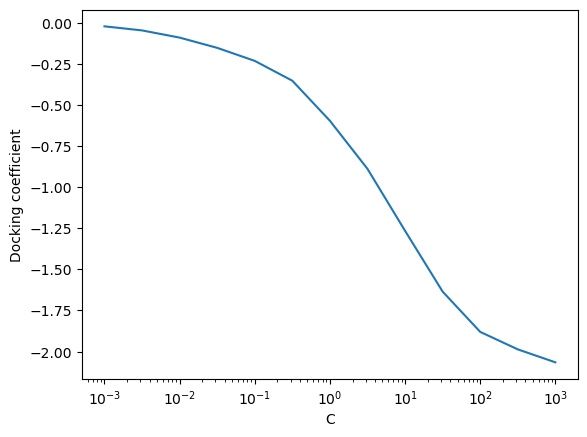

In [279]:
docking_coef = []

for C in Cs:
    df = coef_results[C]
    docking_coef.append(
        df.loc[df["label"].str.contains("docking"), "coef_mean"].iloc[0]
    )

plt.semilogx(Cs, docking_coef)
plt.xlabel("C")
plt.ylabel("Docking coefficient")

In [269]:
print("coef_results")
coef_results[0.100000]

coef_results


,label,coefs,coef_mean,coef_sd,coef_mean/sd,coefs_norm,coefs_max
34,remainder__ARG545.A_Hydrophobic,1.741364,1.741364,0.201677,8.634412,5.596255,1.812849
42,remainder__HIS456.B_PiStacking,1.812849,1.812849,0.226745,7.995108,5.596255,1.812849
30,remainder__GLU543.A_Hydrophobic,1.522710,1.522710,0.285704,5.329671,5.596255,1.812849
12,remainder__HIS456.A_PiStacking,1.038426,1.038426,0.196658,5.280369,5.596255,1.812849
57,remainder__TYR539.B_VdWContact,0.604676,0.604676,0.149842,4.035413,5.596255,1.812849
...,...,...,...,...,...,...,...
33,remainder__GLY544.A_VdWContact,-1.127923,-1.127923,0.180280,-6.256492,5.596255,1.812849
0,dock__docking_score,-0.231386,-0.231386,0.036571,-6.327020,5.596255,1.812849
52,remainder__TYR531.B_VdWContact,-0.934264,-0.934264,0.133667,-6.989500,5.596255,1.812849
31,remainder__GLU543.A_Cationic,-1.322451,-1.322451,0.163000,-8.113174,5.596255,1.812849


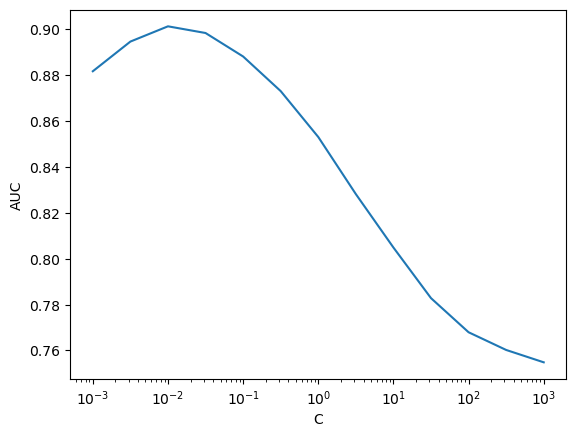

In [267]:
plt.plot([r["C"] for r in results], [r["AUC"] for r in results])
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("AUC")
plt.show()

In [71]:
IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf']

NameError: name 'IFP_frequencies' is not defined

## Scaffold split
I am getting very (suspiciously) high metrics for my IFP (+docking) log reg models. This may be explained by the fact that the actives come from a limited set of scaffolds which are represented in both the training and test folds. Exploration of scaffolds, potentially scaffold split CV.


In [12]:
def get_murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None 
    
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)

    if scaffold.GetNumAtoms() == 0:
        return None 
    
    return Chem.MolToSmiles(scaffold)

In [13]:
montpellier_ligand_data['scaffold'] = montpellier_ligand_data["SMILES"].apply(get_murcko_scaffold)

scaffold_counts = (
    montpellier_ligand_data
    .groupby("scaffold")
    .size()
    .sort_values(ascending=False)
)

scaffold_df = (
    scaffold_counts
    .rename("n_actives")
    .reset_index()
)

print(scaffold_df)

                                             scaffold  n_actives
0                            O=C(CSc1ccccn1)Nc1ccccc1          8
1                         O=C(Nc1ccccc1)c1cc2cccnc2s1          8
2                 O=C(CSc1cccc(-c2ccccc2)n1)Nc1ccccc1          6
3                                            c1ccncc1          5
4              O=C(Nc1ccccc1)c1cc2ccc(-c3ccccc3)nc2s1          5
..                                                ...        ...
82                                 c1ccc(-c2ncco2)cc1          1
83                                 c1ccc(N2CCNCC2)cc1          1
84  c1ccc(CCn2nnnc2C(c2ccccc2)N2CCN(C(c3ccccc3)c3n...          1
85                           c1ccc2nc(N3CCNCC3)ccc2c1          1
86                                    c1ccc2c(c1)OCO2          1

[87 rows x 2 columns]


Problem here is that the rdkit function makes scaffold splits that are too specific, not general enough. One thing I can try is too split the monocyclics (from Rahimova 2017, Ghoteimi 2023, and Grosjean 2025) and the bicyclics (series 4 from Grosjean 2025)

### External validation with monocyclic train set and bicyclic test set

46 active monocyclics, 11 active bicyclics

In [14]:
montpellier_ligand_data.groupby(['bicyclics', 'ACTIVE_LABEL']).size()

bicyclics  ACTIVE_LABEL
False      False           56
           True            46
True       False           28
           True            11
dtype: int64

In [15]:
for conformer_key, dataset in datasets_scaffold.items():
    print(conformer_key)
    print(dataset.keys())


4h2i_c_4
dict_keys(['actives_bicyclics', 'actives_monocyclics', 'decoys_A', 'decoys_B'])
6tve_c_1
dict_keys(['actives_bicyclics', 'actives_monocyclics', 'decoys_A', 'decoys_B'])
6tve_c_2
dict_keys(['actives_bicyclics', 'actives_monocyclics', 'decoys_A', 'decoys_B'])


In [16]:
model_inputs_scaffoldsplit = {}

for conformer_key, dataset in datasets_scaffold.items():

    experiments = {
        "mono_to_bi": {
            "train_actives": dataset["actives_monocyclics"],
            "train_decoys": dataset["decoys_A"],
            "test_actives": dataset["actives_bicyclics"],
            "test_decoys": dataset["decoys_B"],
        },
        "bi_to_mono": {
            "train_actives": dataset["actives_bicyclics"],
            "train_decoys": dataset["decoys_B"],
            "test_actives": dataset["actives_monocyclics"],
            "test_decoys": dataset["decoys_A"],
        },
    }

    model_inputs_scaffoldsplit[conformer_key] = {}

    for split_name, split in experiments.items():

        # ------------------------------------------------------------------
        # Make train dataframe
        # ------------------------------------------------------------------

        train_actives = split["train_actives"]
        train_decoys = split["train_decoys"]

        train_columns = train_actives.columns.union(train_decoys.columns)

        train_actives = train_actives.reindex(columns=train_columns, fill_value=False)
        train_decoys = train_decoys.reindex(columns=train_columns, fill_value=False)

        train = pd.concat(
            [train_actives, train_decoys],
            ignore_index=True,
        )

        # ------------------------------------------------------------------
        # Make test dataframe
        # ------------------------------------------------------------------

        test_actives = split["test_actives"]
        test_decoys = split["test_decoys"]

        test_columns = test_actives.columns.union(test_decoys.columns)

        test_actives = test_actives.reindex(columns=test_columns, fill_value=False)
        test_decoys = test_decoys.reindex(columns=test_columns, fill_value=False)

        test = pd.concat(
            [test_actives, test_decoys],
            ignore_index=True,
        )

        # ------------------------------------------------------------------
        # Ensure train and test have identical feature columns
        # ------------------------------------------------------------------

        all_columns = train.columns.union(test.columns)

        train = train.reindex(columns=all_columns, fill_value=False)
        test = test.reindex(columns=all_columns, fill_value=False)

        model_inputs_scaffoldsplit[conformer_key][split_name] = {

            "X_train": {
                "X_IFP":
                    train.drop(columns=["Active", "LigName", "docking_score"]),
                "X_DOCKING":
                    train[["docking_score"]],
                "X_IFP_DOCKING":
                    train.drop(columns=["Active", "LigName"]),
            },

            "Y_train":
                train["Active"],

            "X_test": {
                "X_IFP":
                    test.drop(columns=["Active", "LigName", "docking_score"]),
                "X_DOCKING":
                    test[["docking_score"]],
                "X_IFP_DOCKING":
                    test.drop(columns=["Active", "LigName"]),
            },

            "Y_test":
                test["Active"],
        }

In [17]:
model_inputs_scaffoldsplit['4h2i_c_4']['mono_to_bi']['X_test']['X_IFP_DOCKING']

,ALA367.A_VdWContact,ALA541.A_HBDonor,ALA541.A_VdWContact,ALA541.B_HBDonor,ALA541.B_VdWContact,ARG545.A_Anionic,ARG545.A_HBDonor,ARG545.A_Hydrophobic,ARG545.A_PiCation,ARG545.A_VdWContact,...,VAL458.A_Hydrophobic,VAL458.A_VdWContact,VAL474.A_Hydrophobic,VAL474.A_VdWContact,VAL474.B_VdWContact,VAL481.A_VdWContact,VAL542.B_HBDonor,VAL542.B_Hydrophobic,VAL542.B_VdWContact,docking_score
0,False,False,False,False,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,-6.83
1,False,False,False,False,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,-6.88
2,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,-6.09
3,False,False,False,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,-5.96
4,False,False,False,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,-6.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2304,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.74
2305,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,-7.87
2306,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,-8.10
2307,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,-7.81


In [18]:
for conformer_key in model_inputs_scaffoldsplit.keys():
    print(model_inputs_scaffoldsplit[conformer_key].keys())

dict_keys(['mono_to_bi', 'bi_to_mono'])
dict_keys(['mono_to_bi', 'bi_to_mono'])
dict_keys(['mono_to_bi', 'bi_to_mono'])


In [19]:
def evaluate_scaffold_dataset(
    X_train,
    Y_train,
    X_test,
    Y_test,
    Cs,
):
    """
    Train on one scaffold and evaluate on the other.

    Hyperparameter tuning is performed only on the
    training scaffold using inner CV.
    """

    has_docking = "docking_score" in X_train.columns

    # --------------------------------------------------
    # Tune hyperparameter on training scaffold
    # --------------------------------------------------

    best_C, tuning_results = tune_hyperparameter(
        X_train,
        Y_train,
        Cs,
        has_docking,
    )

    # --------------------------------------------------
    # Fit final model
    # --------------------------------------------------

    clf = build_pipeline(
        C=best_C,
        has_docking=has_docking,
    )

    clf.fit(
        X_train,
        Y_train,
    )

    # --------------------------------------------------
    # Predict held-out scaffold
    # --------------------------------------------------

    Y_pred = clf.predict_proba(X_test)[:, 1]

    ranking = (
        pd.DataFrame({
            "active": Y_test,
            "score": Y_pred,
        })
        .sort_values("score", ascending=False)
    )

    # --------------------------------------------------
    # Performance metrics
    # --------------------------------------------------

    results = pd.DataFrame([{

        "AUC":
            roc_auc_score(
                ranking["active"],
                ranking["score"],
            ),

        "logAUC":
            logAUC(
                ranking["active"],
                ranking["score"],
            ),

        "EF1%":
            enrichment_factor(
                ranking,
                fraction=0.01,
            ),

        "EF0.1%":
            enrichment_factor(
                ranking,
                fraction=0.001,
            ),

        "BEDROC_80":
            bedroc(
                ranking,
                col=1,
                alpha=80,
            ),

        "selected_C":
            best_C,
    }])

    # --------------------------------------------------
    # Coefficients
    # --------------------------------------------------

    coefs = clf.named_steps["lr"].coef_[0]

    if has_docking:
        feature_names = (
            clf.named_steps["preprocessor"]
            .get_feature_names_out()
        )
    else:
        feature_names = X_train.columns

    coef_df = pd.DataFrame({

        "label":
            feature_names,

        "coef":
            coefs,

        "odds_ratio":
            np.exp(coefs),

    }).sort_values(
        "coef",
        key=np.abs,
        ascending=False,
    )

    tuning_results["selected"] = (
        tuning_results["C"] == best_C
    )

    return results, coef_df, tuning_results

In [20]:
Cs = np.logspace(-3, 3, 13)

all_results_scaffold = {}
all_coef_results_scaffold = {}
all_tuning_results_scaffold = {}

for conformer_key, experiments in model_inputs_scaffoldsplit.items():

    print(f"\nRunning scaffold models for {conformer_key}")

    for split_name, split in experiments.items():

        print(f"  Scaffold split: {split_name}")

        Y_train = split["Y_train"]
        Y_test = split["Y_test"]

        for X_key in split["X_train"]:

            print(f"    Feature set: {X_key}")

            X_train = split["X_train"][X_key]
            X_test = split["X_test"][X_key]

            dataset_name = f"{conformer_key}_{split_name}_{X_key}"

            # --------------------------------------------------------
            # Train on one scaffold, evaluate on the other
            # --------------------------------------------------------

            results, coef_df, tuning_results = evaluate_scaffold_dataset(
                X_train=X_train,
                Y_train=Y_train,
                X_test=X_test,
                Y_test=Y_test,
                Cs=Cs,
            )

            # --------------------------------------------------------
            # Store everything
            # --------------------------------------------------------

            all_results_scaffold[dataset_name] = results
            all_coef_results_scaffold[dataset_name] = coef_df
            all_tuning_results_scaffold[dataset_name] = tuning_results


Running scaffold models for 4h2i_c_4
  Scaffold split: mono_to_bi
    Feature set: X_IFP
    Feature set: X_DOCKING
    Feature set: X_IFP_DOCKING
  Scaffold split: bi_to_mono
    Feature set: X_IFP
    Feature set: X_DOCKING
    Feature set: X_IFP_DOCKING

Running scaffold models for 6tve_c_1
  Scaffold split: mono_to_bi
    Feature set: X_IFP
    Feature set: X_DOCKING
    Feature set: X_IFP_DOCKING
  Scaffold split: bi_to_mono
    Feature set: X_IFP
    Feature set: X_DOCKING
    Feature set: X_IFP_DOCKING

Running scaffold models for 6tve_c_2
  Scaffold split: mono_to_bi
    Feature set: X_IFP
    Feature set: X_DOCKING
    Feature set: X_IFP_DOCKING
  Scaffold split: bi_to_mono
    Feature set: X_IFP
    Feature set: X_DOCKING
    Feature set: X_IFP_DOCKING


In [21]:
all_results_scaffold['4h2i_c_4_mono_to_bi_X_IFP_DOCKING']

,AUC,logAUC,EF1%,EF0.1%,BEDROC_80,selected_C
0,0.980497,0.503455,43.731061,69.969697,0.42938,0.316228


In [22]:
combined_results_scaffold = pd.concat(
    [df.assign(model=name) for name, df in all_results_scaffold.items()],
    ignore_index=True
)
combined_results_scaffold

,AUC,logAUC,EF1%,EF0.1%,BEDROC_80,selected_C,model
0,0.980695,0.504502,43.731061,69.969697,4.311243e-01,0.316228,4h2i_c_4_mono_to_bi_X_IFP
1,0.473554,-0.045348,0.000000,0.000000,3.113158e-12,0.001000,4h2i_c_4_mono_to_bi_X_DOCKING
2,0.980497,0.503455,43.731061,69.969697,4.293803e-01,0.316228,4h2i_c_4_mono_to_bi_X_IFP_DOCKING
3,0.846113,0.329859,21.287625,36.898551,4.000908e-01,0.100000,4h2i_c_4_bi_to_mono_X_IFP
4,0.741235,0.110645,0.000000,0.000000,3.793298e-02,0.316228,4h2i_c_4_bi_to_mono_X_DOCKING
5,0.846565,0.330209,21.287625,36.898551,4.001123e-01,0.100000,4h2i_c_4_bi_to_mono_X_IFP_DOCKING
6,0.866208,0.327893,34.984848,0.000000,2.865831e-01,0.100000,6tve_c_1_mono_to_bi_X_IFP
7,0.517525,-0.031269,0.000000,0.000000,9.429076e-09,0.001000,6tve_c_1_mono_to_bi_X_DOCKING
8,0.865179,0.324678,34.984848,0.000000,2.813488e-01,0.100000,6tve_c_1_mono_to_bi_X_IFP_DOCKING
9,0.720104,0.154898,6.386288,18.449275,1.655214e-01,0.001000,6tve_c_1_bi_to_mono_X_IFP


In [23]:
all_tuning_results_scaffold['4h2i_c_4_mono_to_bi_X_IFP_DOCKING']

,C,AUC,logAUC,EF%1,EF0.1%,BEDROC_80,selected
0,0.001000,0.884722,0.270365,14.901338,0.000000,0.231183,False
1,0.003162,0.899217,0.304136,14.901338,36.898551,0.296245,False
2,0.010000,0.910409,0.335606,17.030100,36.898551,0.348032,False
3,0.031623,0.914026,0.365572,25.545151,36.898551,0.401980,False
4,0.100000,0.912661,0.379666,23.416388,36.898551,0.433967,False
5,0.316228,0.908870,0.381290,23.416388,36.898551,0.445294,True
6,1.000000,0.902991,0.367540,25.545151,36.898551,0.444349,False
7,3.162278,0.894235,0.360903,25.545151,36.898551,0.433282,False
8,10.000000,0.883070,0.347966,23.416388,36.898551,0.404881,False
9,31.622777,0.871122,0.322256,23.416388,36.898551,0.379821,False


In [24]:
all_tuning_results_scaffold['6tve_c_1_mono_to_bi_X_IFP_DOCKING']

,C,AUC,logAUC,EF%1,EF0.1%,BEDROC_80,selected
0,0.001000,0.817235,0.231320,10.643813,18.449275,0.222549,False
1,0.003162,0.848730,0.278356,12.772575,18.449275,0.292106,False
2,0.010000,0.873426,0.318593,17.030100,36.898551,0.348978,False
3,0.031623,0.883009,0.345178,17.030100,36.898551,0.383573,False
4,0.100000,0.883270,0.345860,19.158863,36.898551,0.387891,True
5,0.316228,0.880922,0.338225,17.030100,18.449275,0.365966,False
6,1.000000,0.877617,0.322477,12.772575,18.449275,0.326691,False
7,3.162278,0.874600,0.308788,14.901338,18.449275,0.304980,False
8,10.000000,0.870730,0.293394,12.772575,18.449275,0.277096,False
9,31.622777,0.863826,0.275279,12.772575,0.000000,0.246138,False


In [25]:
all_tuning_results_scaffold['6tve_c_2_mono_to_bi_X_IFP_DOCKING']

,C,AUC,logAUC,EF%1,EF0.1%,BEDROC_80,selected
0,0.001000,0.874757,0.323255,21.287625,36.898551,0.360047,False
1,0.003162,0.883165,0.355836,23.416388,55.347826,0.422215,False
2,0.010000,0.888983,0.380036,29.802676,55.347826,0.476454,False
3,0.031623,0.889609,0.395177,29.802676,55.347826,0.502826,True
4,0.100000,0.886304,0.379714,27.673913,55.347826,0.492630,False
5,0.316228,0.881574,0.372461,27.673913,55.347826,0.484101,False
6,1.000000,0.874391,0.365351,27.673913,55.347826,0.483069,False
7,3.162278,0.864087,0.361050,27.673913,55.347826,0.475609,False
8,10.000000,0.851487,0.351831,27.673913,55.347826,0.472157,False
9,31.622777,0.834800,0.316846,27.673913,36.898551,0.459656,False


### Inspecting IFP coefficients for monocyclic vs bicyclics
Can we distinguish different interactions between the two chemotypes?


In [26]:
all_coef_results_scaffold['4h2i_c_4_mono_to_bi_X_IFP_DOCKING'][all_coef_results_scaffold['4h2i_c_4_mono_to_bi_X_IFP_DOCKING']['coef'].abs() > 1]

,label,coef,odds_ratio
50,remainder__GLU543.A_HBDonor,-2.262247,0.104116
54,remainder__GLU543.B_HBDonor,-2.122019,0.119790
124,remainder__LYS547.B_Anionic,-2.039536,0.130089
79,remainder__HIS456.B_PiStacking,1.920619,6.825185
8,remainder__ARG545.A_Hydrophobic,1.714103,5.551692
51,remainder__GLU543.A_Hydrophobic,1.612880,5.017241
10,remainder__ARG545.A_VdWContact,-1.574256,0.207162
132,remainder__MET535.B_Hydrophobic,1.558211,4.750315
146,remainder__TYR484.A_HBDonor,-1.448707,0.234874
14,remainder__ARG545.B_VdWContact,-1.397243,0.247278


In [27]:
all_coef_results_scaffold['6tve_c_1_mono_to_bi_X_IFP_DOCKING']

,label,coef,odds_ratio
51,remainder__GLU543.B_HBDonor,-1.488647,0.225678
135,remainder__TYR484.A_Hydrophobic,1.475345,4.372546
47,remainder__GLU543.A_HBDonor,-1.322488,0.266471
52,remainder__GLU543.B_Hydrophobic,1.242160,3.463085
114,remainder__LYS547.B_VdWContact,1.236746,3.444388
...,...,...,...
84,remainder__ILE538.B_VdWContact,0.000000,1.000000
85,remainder__LEU363.A_HBDonor,0.000000,1.000000
131,remainder__TRP381.B_Hydrophobic,0.000000,1.000000
149,remainder__TYR539.A_CationPi,0.000000,1.000000


# Final model to predict 1M cmpds
From the nested 5-fold CV hyperparameter optimization followed by performance evaluation, it looks like C=0.1 is the best case for our three X_IFP_DOCKING models
- 2/5 times for 4h2i_c_4 (also 2/5 times 0.316)
- 3/5 times for 6tve_c_1
- 3/5 times for 6tve_c_2

If anything it shows that C is not very sensitive between 0.01-0.316, so 0.1 is a good choice.

In [28]:
print("4h2i_c_4")
print(list(all_results['4h2i_c_4_X_IFP_DOCKING']['selected_Cs']))
print(min(all_results['4h2i_c_4_X_IFP_DOCKING']['selected_Cs'][0]))
print(max(all_results['4h2i_c_4_X_IFP_DOCKING']['selected_Cs'][0]))

print("6tve_c_1")
print(list(all_results['6tve_c_1_X_IFP_DOCKING']['selected_Cs']))
print(min(all_results['6tve_c_1_X_IFP_DOCKING']['selected_Cs'][0]))
print(max(all_results['6tve_c_1_X_IFP_DOCKING']['selected_Cs'][0]))

print("6tve_c_2")
print(list(all_results['6tve_c_2_X_IFP_DOCKING']['selected_Cs']))
print(min(all_results['6tve_c_2_X_IFP_DOCKING']['selected_Cs'][0]))
print(max(all_results['6tve_c_2_X_IFP_DOCKING']['selected_Cs'][0]))


4h2i_c_4
[[np.float64(0.31622776601683794), np.float64(0.1), np.float64(0.1), np.float64(0.03162277660168379), np.float64(0.31622776601683794)]]
0.03162277660168379
0.31622776601683794
6tve_c_1
[[np.float64(0.01), np.float64(0.31622776601683794), np.float64(0.01), np.float64(0.03162277660168379), np.float64(0.01)]]
0.01
0.31622776601683794
6tve_c_2
[[np.float64(0.1), np.float64(0.1), np.float64(0.03162277660168379), np.float64(0.1), np.float64(0.31622776601683794)]]
0.03162277660168379
0.31622776601683794


## Training final models on whole dataset

In [29]:
def train_final_model(X, Y, C=0.1):
    has_docking = "docking_score" in X.columns

    clf = build_pipeline(
        C=C,
        has_docking=has_docking
    )

    clf.fit(X,Y)

    return clf

final_models = {}

for conformer_key, model in model_inputs.items():

    Y = model["Y"]

    for X_key, X in model["X"].items():
        if "X_IFP_DOCKING" not in X_key:
            continue

    final_models[conformer_key] = train_final_model(
        X,
        Y,
        C=0.1
    )
        

## Loading, cleaning vs_screen data
Only the best 5 percent (~ 50 000 cmpds) have been selected

In [30]:
# Import all pickled IFP dictionaries from vs_5percent directory

IFP_vs_pickles = [file for file in os.listdir('./results/vs_results_5percent') if file.endswith('.pkl')]

IFP_vs_dicts = {}

for pickle in IFP_vs_pickles:
    IFP_vs_dicts[pickle] = pd.read_pickle(f"./results/vs_results_5percent/{pickle}")

# Clean up column levels
for run_key, run_dict in IFP_vs_dicts.items():
    run_dict.columns = run_dict.columns.droplevel('ligand')
    run_dict.columns = run_dict.columns.map("_".join)
    if "_" in run_dict.columns:
        run_dict.rename(columns={"_": "LigName"}, inplace=True)


In [31]:
vs_5percent_4h2i_c_4_IFPs = IFP_vs_dicts['4h2i_c_4_percent5.pkl']
vs_5_percent_4h2i_c_4_docking = pd.read_csv("./results/vs_results_5percent/all_results_4h2i_c_4_percent5.csv")[['LigName', 'docking_score']]
vs_5percent_4h2i_c_4 = vs_5percent_4h2i_c_4_IFPs.merge(vs_5_percent_4h2i_c_4_docking, on="LigName")

vs_5percent_6tve_c_1_IFPs = IFP_vs_dicts['6tve_c_1_percent5.pkl']
vs_5_percent_6tve_c_1_docking = pd.read_csv("./results/vs_results_5percent/all_results_6tve_c_1_percent5.csv")[['LigName', 'docking_score']]
vs_5percent_6tve_c_1 = vs_5percent_6tve_c_1_IFPs.merge(vs_5_percent_6tve_c_1_docking, on="LigName")

vs_5percent_6tve_c_2_IFPs = IFP_vs_dicts['6tve_c_2_percent5.pkl']
vs_5_percent_6tve_c_2_docking = pd.read_csv("./results/vs_results_5percent/all_results_6tve_c_2_percent5.csv")[['LigName', 'docking_score']]
vs_5percent_6tve_c_2 = vs_5percent_6tve_c_2_IFPs.merge(vs_5_percent_6tve_c_2_docking, on="LigName")

vs_datasets = {
    "4h2i_c_4": vs_5percent_4h2i_c_4,
    "6tve_c_1": vs_5percent_6tve_c_1,
    "6tve_c_2": vs_5percent_6tve_c_2
}

## Modify IFP columns of vs data
The models trained on the active/decoys use a specific set of IFP interactions as features, so we need to delete the 'excess' columns of the vs IFP data

In [32]:
columns_4h2i_c_4_actives = set(datasets['4h2i_c_4']['actives'].columns)
columns_4h2i_c_4_vs = set(vs_5percent_4h2i_c_4.columns)

both = columns_4h2i_c_4_actives.intersection(columns_4h2i_c_4_vs)
print(f"All IFP columns in 4h2i_c_4 'activea' present in vs: {set_a == both}")

active_not_vs = columns_4h2i_c_4_actives - columns_4h2i_c_4_vs
vs_not_active = columns_4h2i_c_4_vs - columns_4h2i_c_4_actives
print(f"columns present in 42hi active not present in vs: {active_not_vs}")
print(f"columns present in 4h2i vs not present in active: {vs_not_active}")

All IFP columns in 4h2i_c_4 'activea' present in vs: False
columns present in 42hi active not present in vs: {'Active'}
columns present in 4h2i vs not present in active: {'LYS547.B_Anionic', 'CYS476.A_VdWContact', 'PRO540.B_HBDonor', 'ASP473.B_VdWContact', 'SER483.A_HBDonor', 'ILE455.A_HBDonor', 'PRO540.A_HBDonor', 'TYR539.B_CationPi', 'TYR539.A_CationPi', 'LYS547.A_PiCation', 'TYR539.B_HBDonor', 'ASP366.A_HBDonor', 'GLU543.B_HBDonor', 'ASP366.B_HBDonor', 'ASP473.A_VdWContact', 'LEU363.A_Hydrophobic', 'ASP366.A_Cationic', 'TYR484.A_HBDonor', 'LYS471.A_Anionic', 'LYS547.A_Hydrophobic', 'GLY544.A_HBDonor', 'ASN362.B_Hydrophobic', 'ASN370.A_VdWContact', 'ARG545.A_Anionic', 'VAL542.A_VdWContact', 'GLU543.A_HBDonor', 'TYR531.A_HBDonor', 'VAL542.B_HBDonor', 'ARG545.B_VdWContact', 'LEU373.A_Hydrophobic', 'LYS471.B_VdWContact', 'VAL384.A_HBDonor', 'LEU475.B_Hydrophobic', 'VAL452.A_VdWContact', 'TYR484.B_HBDonor', 'LYS547.B_PiCation', 'LYS471.B_Anionic', 'TYR539.A_HBDonor', 'HIS456.A_Hydrophobi

In [33]:
model_inputs['4h2i_c_4']['X']['X_IFP_DOCKING'].columns

Index(['ALA367.A_VdWContact', 'ALA541.A_HBDonor', 'ALA541.A_VdWContact',
       'ALA541.B_HBDonor', 'ALA541.B_VdWContact', 'ARG545.A_Anionic',
       'ARG545.A_HBDonor', 'ARG545.A_Hydrophobic', 'ARG545.A_PiCation',
       'ARG545.A_VdWContact',
       ...
       'VAL458.A_Hydrophobic', 'VAL458.A_VdWContact', 'VAL474.A_Hydrophobic',
       'VAL474.A_VdWContact', 'VAL474.B_VdWContact', 'VAL481.A_VdWContact',
       'VAL542.B_HBDonor', 'VAL542.B_Hydrophobic', 'VAL542.B_VdWContact',
       'docking_score'],
      dtype='str', length=189)

In [34]:
vs_model_inputs = {}

for conformer_key, vs_dataset in vs_datasets.items():
    print("\n")
    print(f"Dataframe information for {conformer_key}")
    print(f"shape model training input: {model_inputs[conformer_key]['X']['X_IFP_DOCKING'].shape}")
    print(f"shape vs: {vs_dataset.shape}")


    set_model = set(model_inputs[conformer_key]['X']['X_IFP_DOCKING'].columns)
    set_vs = set(vs_datasets[conformer_key].columns)

    model_not_vs = set_model - set_vs
    vs_not_model = set_vs - set_model
    print(f"Number of columns in model training input not present in vs: {len(model_not_vs)}: {model_not_vs}")
    print(f"Number of columns in vs not present in model training input: {len(vs_not_model)}: {vs_not_model}")

    columns_in_model_and_vs = set_model.intersection(set_vs)
    print(f"Number of columns in both model training input and vs : {len(columns_in_model_and_vs)}")

    # todo: make X_IFP_DOCKING for vs data by only keeping the columns present in the model training input features, and also create any missing model input feature columns and set them to False
    training_columns = model_inputs[conformer_key]["X"]["X_IFP_DOCKING"].columns

    X_IFP_DOCKING = (
    vs_dataset
    .reindex(columns=training_columns)
    )

    # Missing binary interaction features are absent -> no interaction
    binary_cols = X_IFP_DOCKING.columns.difference(["docking_score"])
    X_IFP_DOCKING[binary_cols] = X_IFP_DOCKING[binary_cols].fillna(False)

    # Docking score should never be missing
    assert X_IFP_DOCKING["docking_score"].notna().all()

    assert list(X_IFP_DOCKING.columns) == list(training_columns)

    vs_model_inputs[conformer_key] = X_IFP_DOCKING




Dataframe information for 4h2i_c_4
shape model training input: (4855, 189)
shape vs: (38064, 153)
Number of columns in model training input not present in vs: 44: {'ASP485.B_VdWContact', 'ILE406.B_VdWContact', 'GLY404.B_VdWContact', 'MET386.A_VdWContact', 'VAL474.B_VdWContact', 'ILE398.B_VdWContact', 'ILE406.B_HBDonor', 'LEU346.B_Hydrophobic', 'LYS341.B_VdWContact', 'THR342.B_VdWContact', 'ILE343.B_Hydrophobic', 'ASN362.A_HBDonor', 'THR405.B_VdWContact', 'VAL474.A_VdWContact', 'VAL481.A_VdWContact', 'HIS383.A_Hydrophobic', 'VAL474.A_Hydrophobic', 'MET368.A_VdWContact', 'CYS365.A_VdWContact', 'LEU346.B_VdWContact', 'ILE364.A_VdWContact', 'ALA367.A_VdWContact', 'CYS358.B_VdWContact', 'ASN359.A_Hydrophobic', 'ASN372.A_VdWContact', 'ILE538.B_Hydrophobic', 'ASP473.A_Cationic', 'ASN359.B_VdWContact', 'VAL384.A_Hydrophobic', 'ASP485.A_Hydrophobic', 'ILE369.A_HBDonor', 'ASP485.A_VdWContact', 'LEU472.A_VdWContact', 'PRO486.B_VdWContact', 'GLU357.B_VdWContact', 'ILE455.A_Hydrophobic', 'LEU472.

In [35]:
vs_model_inputs['4h2i_c_4']

,ALA367.A_VdWContact,ALA541.A_HBDonor,ALA541.A_VdWContact,ALA541.B_HBDonor,ALA541.B_VdWContact,ARG545.A_Anionic,ARG545.A_HBDonor,ARG545.A_Hydrophobic,ARG545.A_PiCation,ARG545.A_VdWContact,...,VAL458.A_Hydrophobic,VAL458.A_VdWContact,VAL474.A_Hydrophobic,VAL474.A_VdWContact,VAL474.B_VdWContact,VAL481.A_VdWContact,VAL542.B_HBDonor,VAL542.B_Hydrophobic,VAL542.B_VdWContact,docking_score
0,False,False,False,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,-9.78
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,-10.26
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,-9.81
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-9.88
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-10.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38059,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,-9.80
38060,False,False,False,False,False,False,False,True,True,True,...,False,False,False,False,False,False,False,False,False,-9.77
38061,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-9.77
38062,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,-10.51


## Predicting on vs data

In [36]:
vs_predictions = {}

for conformer_key, model in final_models.items():

    pred = model.predict_proba(
        vs_model_inputs[conformer_key]
    )[:, 1]

    vs_predictions[conformer_key] = (
        vs_datasets[conformer_key][["LigName", "docking_score"]]
        .assign(LR_score=pred)
        .sort_values("LR_score", ascending=False)
        .reset_index(drop=True)
    )

In [37]:
vs_predictions_combined = (
    vs_predictions["4h2i_c_4"][["LigName", "LR_score"]]
    .rename(columns={"LR_score": "4h2i_score"})
    .merge(
        vs_predictions["6tve_c_1"][["LigName", "LR_score"]]
        .rename(columns={"LR_score": "6tve1_score"}),
        on="LigName",
        how="outer",
    )
    .merge(
        vs_predictions["6tve_c_2"][["LigName", "LR_score"]]
        .rename(columns={"LR_score": "6tve2_score"}),
        on="LigName",
        how="outer",
    )
)

In [38]:
score_cols = [
    "4h2i_score",
    "6tve1_score",
    "6tve2_score",
]

scores = vs_predictions_combined[score_cols].fillna(0)

vs_predictions_combined["mean_score"] = scores.mean(axis=1)
vs_predictions_combined["min_score"] = scores.min(axis=1)
vs_predictions_combined["max_score"] = scores.max(axis=1)
vs_predictions_combined["sum_score"] = scores.sum(axis=1)
vs_predictions_combined["n_conformers"] = vs_predictions_combined[score_cols].notna().sum(axis=1)

In [39]:
vs_predictions_combined.sort_values(
    ["mean_score", "n_conformers"],
    ascending=False,
)

,LigName,4h2i_score,6tve1_score,6tve2_score,mean_score,min_score,max_score,sum_score,n_conformers
60831,21179308,0.883756,0.867134,0.981050,9.106466e-01,0.867134,0.981050,2.731940,3
70686,21333722,0.989469,0.869317,0.723416,8.607337e-01,0.723416,0.989469,2.582201,3
31448,20537755,0.964429,0.572475,0.929447,8.221171e-01,0.572475,0.964429,2.466351,3
41919,20813559,0.965136,0.894675,0.425577,7.617960e-01,0.425577,0.965136,2.285388,3
16460,19880088,0.479951,0.901683,0.817920,7.331843e-01,0.479951,0.901683,2.199553,3
...,...,...,...,...,...,...,...,...,...
72391,21344911-again1,0.000003,NaN,NaN,1.010351e-06,0.000000,0.000003,0.000003,1
74792,21369881-again1,NaN,NaN,0.000002,7.539234e-07,0.000000,0.000002,0.000002,1
62013,21227271-again1,NaN,0.000002,NaN,6.296168e-07,0.000000,0.000002,0.000002,1
73856,21352859-again1,0.000002,NaN,NaN,5.080864e-07,0.000000,0.000002,0.000002,1


In [40]:
vs_predictions_combined.sort_values(
    ["min_score", "mean_score"],
    ascending=False,
)

,LigName,4h2i_score,6tve1_score,6tve2_score,mean_score,min_score,max_score,sum_score,n_conformers
60831,21179308,0.883756,0.867134,0.981050,9.106466e-01,0.867134,0.981050,2.731940,3
70686,21333722,0.989469,0.869317,0.723416,8.607337e-01,0.723416,0.989469,2.582201,3
35284,20591133,0.617673,0.664398,0.774087,6.853860e-01,0.617673,0.774087,2.056158,3
44891,20855072,0.636735,0.612021,0.809923,6.862267e-01,0.612021,0.809923,2.058680,3
31862,20539169,0.708143,0.820149,0.606011,7.114342e-01,0.606011,0.820149,2.134303,3
...,...,...,...,...,...,...,...,...,...
72391,21344911-again1,0.000003,NaN,NaN,1.010351e-06,0.000000,0.000003,0.000003,1
74792,21369881-again1,NaN,NaN,0.000002,7.539234e-07,0.000000,0.000002,0.000002,1
62013,21227271-again1,NaN,0.000002,NaN,6.296168e-07,0.000000,0.000002,0.000002,1
73856,21352859-again1,0.000002,NaN,NaN,5.080864e-07,0.000000,0.000002,0.000002,1


## Inspecting coefficients of final models

In [41]:
final_model_coefs = {}

for final_model in final_models:
    feature_labels = final_models[final_model].named_steps['preprocessor'].get_feature_names_out()
    feature_coefs = final_models[final_model].named_steps['lr'].coef_[0]

    final_model_df = pd.DataFrame({
        "label": feature_labels,
        "coef": feature_coefs
    })

    final_model_coefs[final_model] = final_model_df


In [49]:
# "near zero" coefficients
for final_model in final_model_coefs:
    total_coefs = final_model_coefs[final_model].shape[0]
    near_zeros = final_model_coefs[final_model].loc[final_model_coefs[final_model]['coef'].abs() < 0.01].shape[0]
    print(f"total coefs: {total_coefs}")
    print(f"near zeros: {near_zeros}, ({near_zeros / total_coefs})")

total coefs: 189
near zeros: 45, (0.23809523809523808)
total coefs: 174
near zeros: 36, (0.20689655172413793)
total coefs: 178
near zeros: 42, (0.23595505617977527)


In [43]:
final_model_coefs['4h2i_c_4'].sort_values('coef', key=abs, ascending=False).head(20)

,label,coef
50,remainder__GLU543.A_HBDonor,-1.802436
124,remainder__LYS547.B_Anionic,-1.743825
79,remainder__HIS456.B_PiStacking,1.656980
8,remainder__ARG545.A_Hydrophobic,1.649725
54,remainder__GLU543.B_HBDonor,-1.636605
51,remainder__GLU543.A_Hydrophobic,1.507516
10,remainder__ARG545.A_VdWContact,-1.402577
132,remainder__MET535.B_Hydrophobic,1.158624
157,remainder__TYR531.A_VdWContact,-1.129066
6,remainder__ARG545.A_Anionic,-1.083753


The feature weights (coefficients) of the trained Ridge logistic regression (LR) models can be interpreted to shed light on which interactions are important for activity prediction. A large coefficient indicates that the model strongly rewards or penalizes (depending on the sign) a particular ligand-residue interaction as encoded by an IFP bit. Some interactions were found to be weighted consistently strongly between the three LR models (trained on IFP calculations stemming from best-scoring docking poses on the final three conformers). Examples are the hydrogen bond donating interaction with the Glu-543 residues of both chain A and B (`GLU543.A_HBDonor`, `GLU543.B_HBDonor`), being found in the top 5 most strongly weighted interactions for all three models (coefficients: -2.07 - -1.70), or the His-456B $\pi$-stacking interaction (`HIS456.B_PiStacking`), being found in the top 10 most strongly weighted interactions (+1.42, +1.46) for the `4H2I_c_4` (closed) and `6TVE_C_2` (open) models. Interestingly, the hydrogen bonding interactions with the Glu-543 residues were previously found to be observed in docking poses for the most active inhibitors (Rahimova 2018), which seemingly contradicts the large, negative coefficients in our LR models (despite their good enrichment metrics). However, both this work and the previous study use (best-scoring) tentative docking poses which have not been verified experimentally, which limits its intepretation. On the other hand, the coefficients of the interaction with His-456B do agree with docking results observed previously (Rahimova 2018, Ghoteimi 2023).

Even interactions weighted with modest coefficients can, however, still significantly contribute to the predictions, especially when they consistently occur in concert with a subset of other interactions (e.g. contributed by a local group of residue sidechains). In these cases, the sum of these regularized coefficients could be just as large, if not larger than important invididual IFPs and substanitally influence activity predictions. Correlation plots for the IFP features reveal hotspot clusters of nearby residues with high correlation coefficients **TO-DO: Include correlation matrix figures**. For example, in the `4H2I_c_4` LR model, the IFP feature encoding Van der Waals interactions with Leu-373A (coefficient -0.11) and the nearby Val-384A (-0.12) are very highly correlated ($\rho = 0.79$) **TO-DO: include figure showcasing location of Leu373 and nearby's**, meaning that despite their small individual weights, they often both contribute to the activity predictions in concert, in equal direction (both disfavoring activity) with greater influence. A complication that results from the inclusion of Van der Waals interactions to the IFP features, is that they can lead to drastic shrinkage of more physically interpretable interactions with the same residue (like hydrogen bonds, hydrophobic interactions, or salt bridges). This is the case for the aforementioned Leu-373A residue, whose Van der Waals-, and hydrophobic IFPs are both included in the model. For this residue, the hydrophobic coefficient has shrunk to near-zero (-0.01), because it is essentially encoding the same interaction (it would be expected that the type of interactions ligand would make are almost always hydrophobic due to its aliphatic sidechain). Still, it was chosen to include the Van der Waals interaction features in the LR models due to the absence of any experimental binding poses which could help to construct a more specific selection of key interactions. Furthermore, the Van der Waals-IFPs can still contribute information by encoding 'geometric' features (i.e. the orientation of ligands in the dimer interface, protrusion in to subpockets). This can explain the slightly better cross-validated metrics (AUC, BEDROC80, etc) for the full IFP LR models compared to the models which exclude these interactions. **TO-DO: show table**

The L2 (Ridge) regularization shrank the coefficients of many IFP features considerably (absolute value < 0.1), indicating that these interactions contributed minimally to activity predictions. This could possibly be explained by an interaction occuring very rarely, causing the model to not be able to give reliable estimates duting traning, or a frequent interaction that is likely to occur in both actives and decoys and therefore carrying no predictive signal. In total, these IFPs encompassed around 45% of all features (87 / 189 (46.0%) for `4H2I_c_4`, 74 / 174 (42.5%) for `6TVE_c_1`, and 78 / 178 (43.8%) for the `6TVE_c_2` LR model). Across the models, around 20% of features were shrank to 'near-zero' (absolute value < 0.01) and *effectively* excluded from contributing to activity predictions (45 / 189 (23.8%) for `4H2I_c_4`, 36 / 174 (20.6%) for `6TVE_c_1`, and 42 / 178 (23.6%) for `6TVE_c_2`). L1 (Lasso) regularization, which can *actually* select unimportant features out of the model, was tried as an alternative. However, the L2 regularization approach consistently achieved superior cross-validated metrics. Furthermore, the L1 regularization frequently led to overly sparse models, including models with no features at all.  **TO-DO: add Lasso regression metrics tabel to Appendix**


In [101]:
corr = model_inputs['4h2i_c_4']['X']['X_IFP'].corr()
corr_4h2i_c_4 = corr
corr_6tve_c_1 = model_inputs['6tve_c_1']['X']['X_IFP'].corr()
corr_6tve_c_2 = model_inputs['6tve_c_2']['X']['X_IFP'].corr()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=np.abs, ascending=False)
)
corr_pairs[corr_pairs < 1.0][0:10]

LEU373.A_VdWContact   VAL384.A_VdWContact     0.799268
ASP485.A_VdWContact   PRO486.A_VdWContact     0.790325
HIS456.A_Hydrophobic  LYS547.A_Hydrophobic    0.761250
ASN372.A_VdWContact   MET386.A_VdWContact     0.707034
ASP485.A_Hydrophobic  ILE364.A_VdWContact     0.707034
ASN372.A_VdWContact   VAL384.A_Hydrophobic    0.707034
ILE546.A_VdWContact   THR342.B_VdWContact     0.707034
                      VAL384.A_Hydrophobic    0.707034
                      LEU346.B_VdWContact     0.707034
                      MET386.A_VdWContact     0.707034
dtype: float64

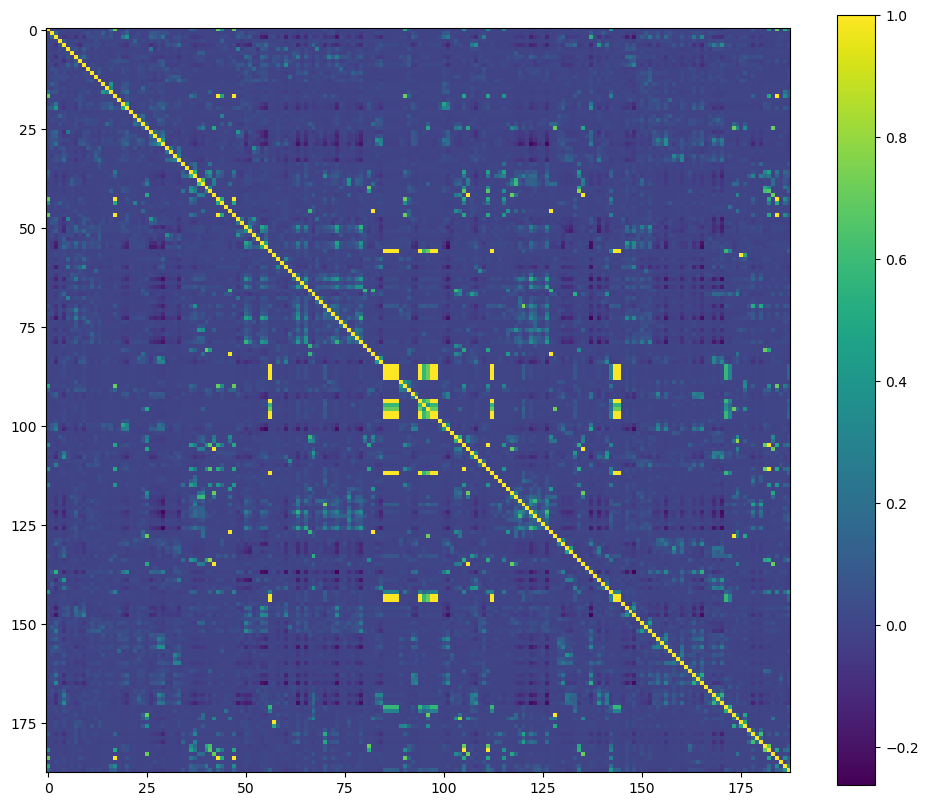

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.imshow(corr_4h2i_c_4)
plt.colorbar()
#plt.xticks(range(len(corr)), corr.columns, rotation=90)
#plt.yticks(range(len(corr)), corr.columns)
plt.show()

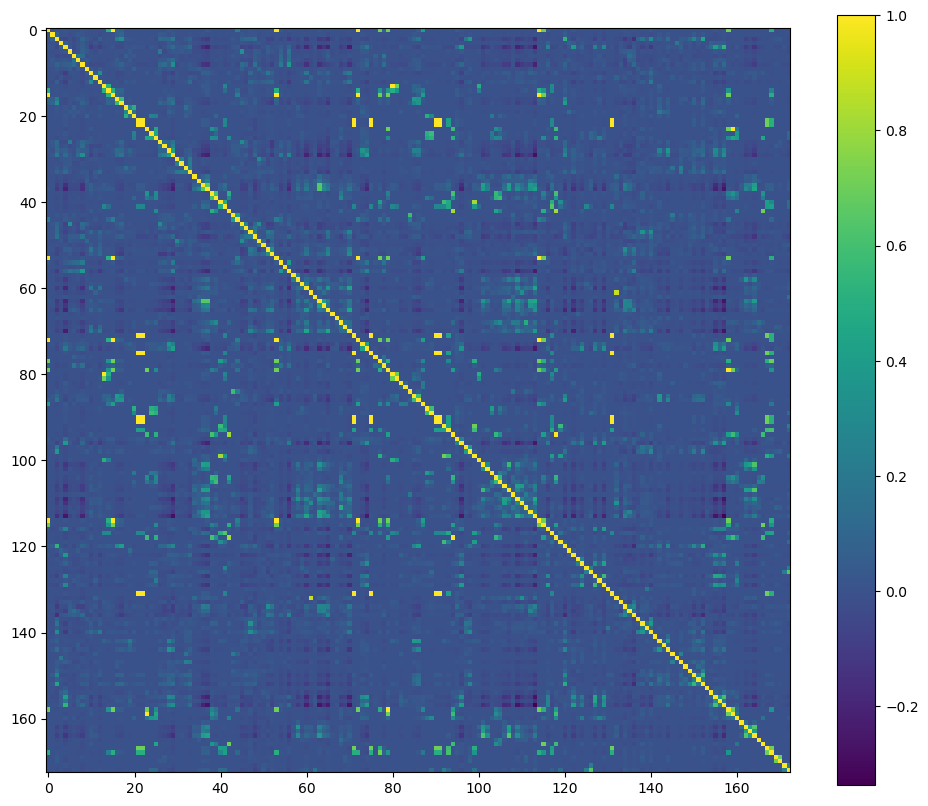

In [103]:
plt.figure(figsize=(12,10))
plt.imshow(corr_6tve_c_1)
plt.colorbar()
#plt.xticks(range(len(corr)), corr.columns, rotation=90)
#plt.yticks(range(len(corr)), corr.columns)
plt.show()

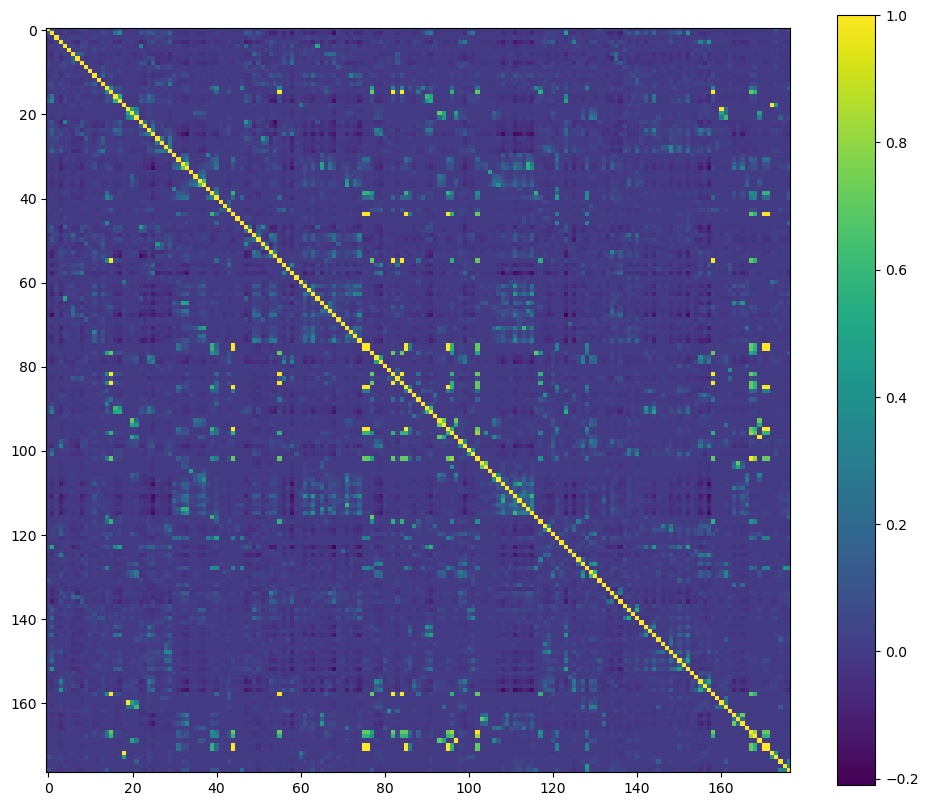

In [104]:
plt.figure(figsize=(12,10))
plt.imshow(corr_6tve_c_2)
plt.colorbar()
#plt.xticks(range(len(corr)), corr.columns, rotation=90)
#plt.yticks(range(len(corr)), corr.columns)
plt.show()

In [107]:
s = corr_pairs
ifp = "ARG545.A_Anionic"

result = s[
    (s.index.get_level_values(0) == ifp) |
    (s.index.get_level_values(1) == ifp)
]

print(result)
print(f"{final_model_coefs['4h2i_c_4'][final_model_coefs['4h2i_c_4']['label'] == "remainder__HIS456.A_Hydrophobic"]}")

ARG545.A_Anionic      HIS456.A_Anionic       0.287660
                      GLU543.A_Cationic      0.285145
                      ASP366.A_Cationic      0.243289
                      GLY454.A_VdWContact    0.215263
                      GLY453.A_VdWContact    0.146462
                                               ...   
VAL474.B_VdWContact   ARG545.A_Anionic            NaN
VAL481.A_VdWContact   ARG545.A_Anionic            NaN
VAL542.B_HBDonor      ARG545.A_Anionic            NaN
VAL542.B_Hydrophobic  ARG545.A_Anionic            NaN
VAL542.B_VdWContact   ARG545.A_Anionic            NaN
Length: 375, dtype: float64
                              label      coef
71  remainder__HIS456.A_Hydrophobic -0.883119
